In [48]:
import os
# Directory to save model checkpoints
save_dir = './checkpoints'
os.makedirs(save_dir, exist_ok=True)
#Save model after each epoch
def save_model(model, optimizer, avg_loss, test_accuracy, epoch):
        checkpoint_path = os.path.join('./checkpoints', f'model_epoch_{epoch + 1}.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'accuracy': test_accuracy
        }, checkpoint_path)

        print(f'Model saved at {checkpoint_path}')

In [49]:
from torchvision.datasets import ImageFolder

class ImageFolderWithFilenames(ImageFolder):
    def __getitem__(self, index):
        # Get the original tuple of (image, label)
        original_tuple = super().__getitem__(index)
        
        # Get the image path and extract the filename
        path, _ = self.samples[index]
        filename = os.path.basename(path)
        
        # Return image, label, and filename
        return original_tuple[0], original_tuple[1], filename


In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_loss_list = []
test_accuracy_list = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')  # Prints 'cuda' if GPU is available, else 'cpu'

batch_size = 64
learning_rate = 0.001
num_epochs = 5
image_size = (480, 960)  # Image size
color_channel = 1 # only grayscale, so 1 channel is enough

# Define the transformations (resize, normalize, convert to tensor)
transform = transforms.Compose([
    transforms.Resize(image_size),  # Resize images to 960x480 pixels
    transforms.Grayscale(num_output_channels=color_channel),  # Convert to grayscale (1 channel)
    transforms.ToTensor(),  # Convert the image to PyTorch tensor
    transforms.Normalize((0.5), (0.5))  # Normalize the image between -1 and 1
])

# Load the datasets
train_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Training Image Dataset', transform=transform)
# test_dataset = datasets.ImageFolder(root='/home/zubair/Downloads/CNN Data/Test Image Dataset 1', transform=transform)
test_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Test Image Dataset 1', transform=transform)
# DataLoader (to handle batch processing)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

Using device: cuda


In [51]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # shap expects CNN  to have self.conv_layers and self.fc_layers
        # Define the convolutional layers using nn.Sequential
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=color_channel, out_channels=16, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Calculate the size of the flattened output after conv + pooling
        conv_output_size = self._get_conv_output_size(image_size)

        # Define the fully connected layers using nn.Sequential
        self.fc_layers = nn.Sequential(
            nn.Linear(conv_output_size, 128),  # First fully connected layer
            nn.ReLU(),
            #nn.Dropout(),  # Add dropout for regularization
            nn.Linear(128, len(train_dataset.classes))  # Output layer
        )

    def forward(self, x):
        x = self.conv_layers(x)  # Pass through convolutional layers
        x = x.reshape(x.size(0), -1)  # Flatten the tensor
        x = self.fc_layers(x)  # Pass through fully connected layers
        return x

    def _get_conv_output_size(self, img_size):
        """Helper function to calculate the size of the tensor after conv + pool."""
        with torch.no_grad():
            dummy_input = torch.ones(1, color_channel, *img_size).to(device)  # Dummy input
            x = self.conv_layers(dummy_input)  # Pass through conv layers
            return x.numel()  # Return the flattened size

In [52]:
model = SimpleCNN().to(device)  # Move the model to the GPU/CPU
criterion = nn.CrossEntropyLoss()  # Cross entropy loss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Modify the training function to save loss, accuracy, and model
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    model.train()  # Set the model to training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        # Training loop
        for images, labels, filenames in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute the loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update the weights
            running_loss += loss.item()
        # Average loss for the epoch
        avg_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_loss)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}')
        # Test accuracy at the end of each epoch
        test_accuracy = test_model(model, test_loader, device)
        test_accuracy_list.append(test_accuracy)
        # save_model(model, optimizer, avg_loss, test_accuracy, epoch);
    return train_loss_list, test_accuracy_list

# Modify the test function to return accuracy
def test_model(model, test_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # No need to track gradients for testing
        for images, labels, fileNames in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return accuracy

# Train the model and save metrics
train_loss_list, test_accuracy_list = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs,
                                                  device)

Epoch [1/5], Loss: 4.2042
Accuracy of the model on the test images: 87.19%
Epoch [2/5], Loss: 0.0723
Accuracy of the model on the test images: 89.46%
Epoch [3/5], Loss: 0.0207
Accuracy of the model on the test images: 88.84%
Epoch [4/5], Loss: 0.0039
Accuracy of the model on the test images: 89.05%
Epoch [5/5], Loss: 0.0007
Accuracy of the model on the test images: 89.46%


In [53]:
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
target_layer = model.conv_layers[-1]
cam = GradCAM(model=model, target_layers=[target_layer])
def showGradcamOuputput(input_image, label, fileName, imageIndex):
    input_image = input_image.unsqueeze(0)  # add batch as first dim, so Shape becomes (1, 1, H, W)
    input_image = input_image.to(device)
    grayscale_cam = cam(input_tensor=input_image, targets=None)[0]  # No need to specify target for single-label dataset
    # Convert the input image to a NumPy array for visualization
    input_image_np = input_image.squeeze(0).cpu().numpy()  # Remove batch and channel dimensions
    input_image_np = (input_image_np - input_image_np.min()) / (input_image_np.max() - input_image_np.min())  # Normalize [0, 1]
    input_image_np = input_image_np.transpose((1, 2, 0))
    # Overlay the heatmap
    visualization = show_cam_on_image(input_image_np, grayscale_cam, use_rgb=False)
    
    plt.figure(figsize=(30, 15))  # Adjust aspect ratio (12:6 = 960:480 for 80 dpi)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM Heatmap: class: {label}, filename: {fileName}")
    plt.axis("off")
    plt.savefig(os.path.join("explained_images/", f"gradCam_image_{imageIndex}.png"), dpi=300)
    plt.show()

In [54]:
import shap
shap_loader = torch.utils.data.DataLoader(train_dataset, batch_size=20, shuffle=True)
shap_loader_imagesNLabels = next(iter(shap_loader))
shap_images, shap_labels, image_file_names = shap_loader_imagesNLabels  # Get the first batch of images
background_images = shap_images[:]  #batch, channel,h ,w
model.eval()
e = shap.DeepExplainer(model.cpu(), background_images.cpu())
test_images = shap_images[: -5]
test_labels = shap_labels[: -5]
tets_image_fileNames = image_file_names[: -5]

shap_values = e.shap_values(test_images.cpu())  #batch, channel,h ,w, class
shap_values = np.transpose(shap_values, (4, 0, 2, 3, 1))  #class, batch, h ,w, channel
shap_values = list(shap_values)  #class list of each batch, h ,w, channel

In [55]:
import matplotlib.pyplot as pl
import os
print("Current working directory:", os.getcwd())
# Define output directory
output_directory = "explained_images/"
os.makedirs(output_directory, exist_ok=True)  # Create the directory if it doesn't exist

def ouptutForShap(shap_values, test_image, label, fileName, imageIndex):
    shap_pixel_values = np.swapaxes(test_image.numpy(), 1, -1)  #b,h,w,c
    shap_pixel_values = np.swapaxes(shap_pixel_values, 1, 2)
    shap.image_plot(shap_values, shap_pixel_values,  show = False) #  , labels=['predictedLabels11' , 'predictedLabels22'], true_labels = ['trueLabels11']
    plt.gcf().set_size_inches(30, 30)  # Set the figure size to be larger
    plt.suptitle(f"SHAP Exp for {fileName}. TrueLabel: {label}", fontsize=20)  # Add a title with custom font size
    plt.savefig(os.path.join(output_directory, f"shap_image_{imageIndex}.png"), dpi=300)
    pl.show()

Current working directory: /home/zubair/zPycharmProjects/pythonProject/birdSongClassifier


In [56]:
from skimage.segmentation import mark_boundaries
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

class LimeCNNWrapper:
    def __init__(self, model, device):
        self.model = model
        self.device = device
    def predict(self, images):
        # Convert numpy image (batch) to tensor; now images are batch, h, w, c : 10, 960, 480, 3
        # lime sends as batch, h, w, c ;; now average on channel dim, as lime is forefully sending 3 channels.
        if images.shape[-1] == 3:
            images = np.mean(images, axis=-1, keepdims=True)
        images = torch.tensor(images).permute(0, 3, 1, 2).float()  # Convert to (batch, channels, height, width);; cuz my predict fun expects this format
        images = images.to(self.device)
        with torch.no_grad():
            outputs = self.model(images)
            probabilities = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()
        return probabilities
    
# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()
# Create a wrapper for the model
model = model.to(device)
lime_cnn_model_wrapper = LimeCNNWrapper(model, device)
# Create a SegmentationAlgorithm object with 'slic' algorithm
segmentation_fn = SegmentationAlgorithm('slic', n_segments=100, compactness=1, sigma=1)

In [57]:
def showLimeOutput(limeExplainer, limeCNNWrapper, segmentation_fn, test_image, test_label, fileName, imageIndex):
    if test_label is not None:
        image, label = test_image, test_label  # Get one image from your test dataset
    else :
        image, label = test_image
    image_np = image.numpy().transpose(1, 2, 0)  # Convert tensor to numpy for LIME
    image_np = np.squeeze(image_np) # remove channel dimension
    # Explain the model's prediction for this specific image
    explanation = limeExplainer.explain_instance(image_np, 
                                             limeCNNWrapper.predict, 
                                             top_labels=2, 
                                             hide_color=0, 
                                             num_samples=100,
                                             segmentation_fn=segmentation_fn)
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                                positive_only=False,
                                                num_features=5,
                                                hide_rest=False)
    # Display the image with explanations
    img_boundaries = mark_boundaries(temp, mask, color = (0, 0, 1))
    plt.figure(figsize=(30, 15))
    plt.imshow(img_boundaries / 2 + 0.5 )  # Unnormalize the image
    plt.axis('off')
    plt.title(f'LIME Explanation-> TrueLabel: {label}, prediction: {explanation.top_labels[0]}, fileName: {fileName}')
    plt.savefig(os.path.join(output_directory, f"lime_image_{imageIndex}.png"), dpi=300)
    plt.show()

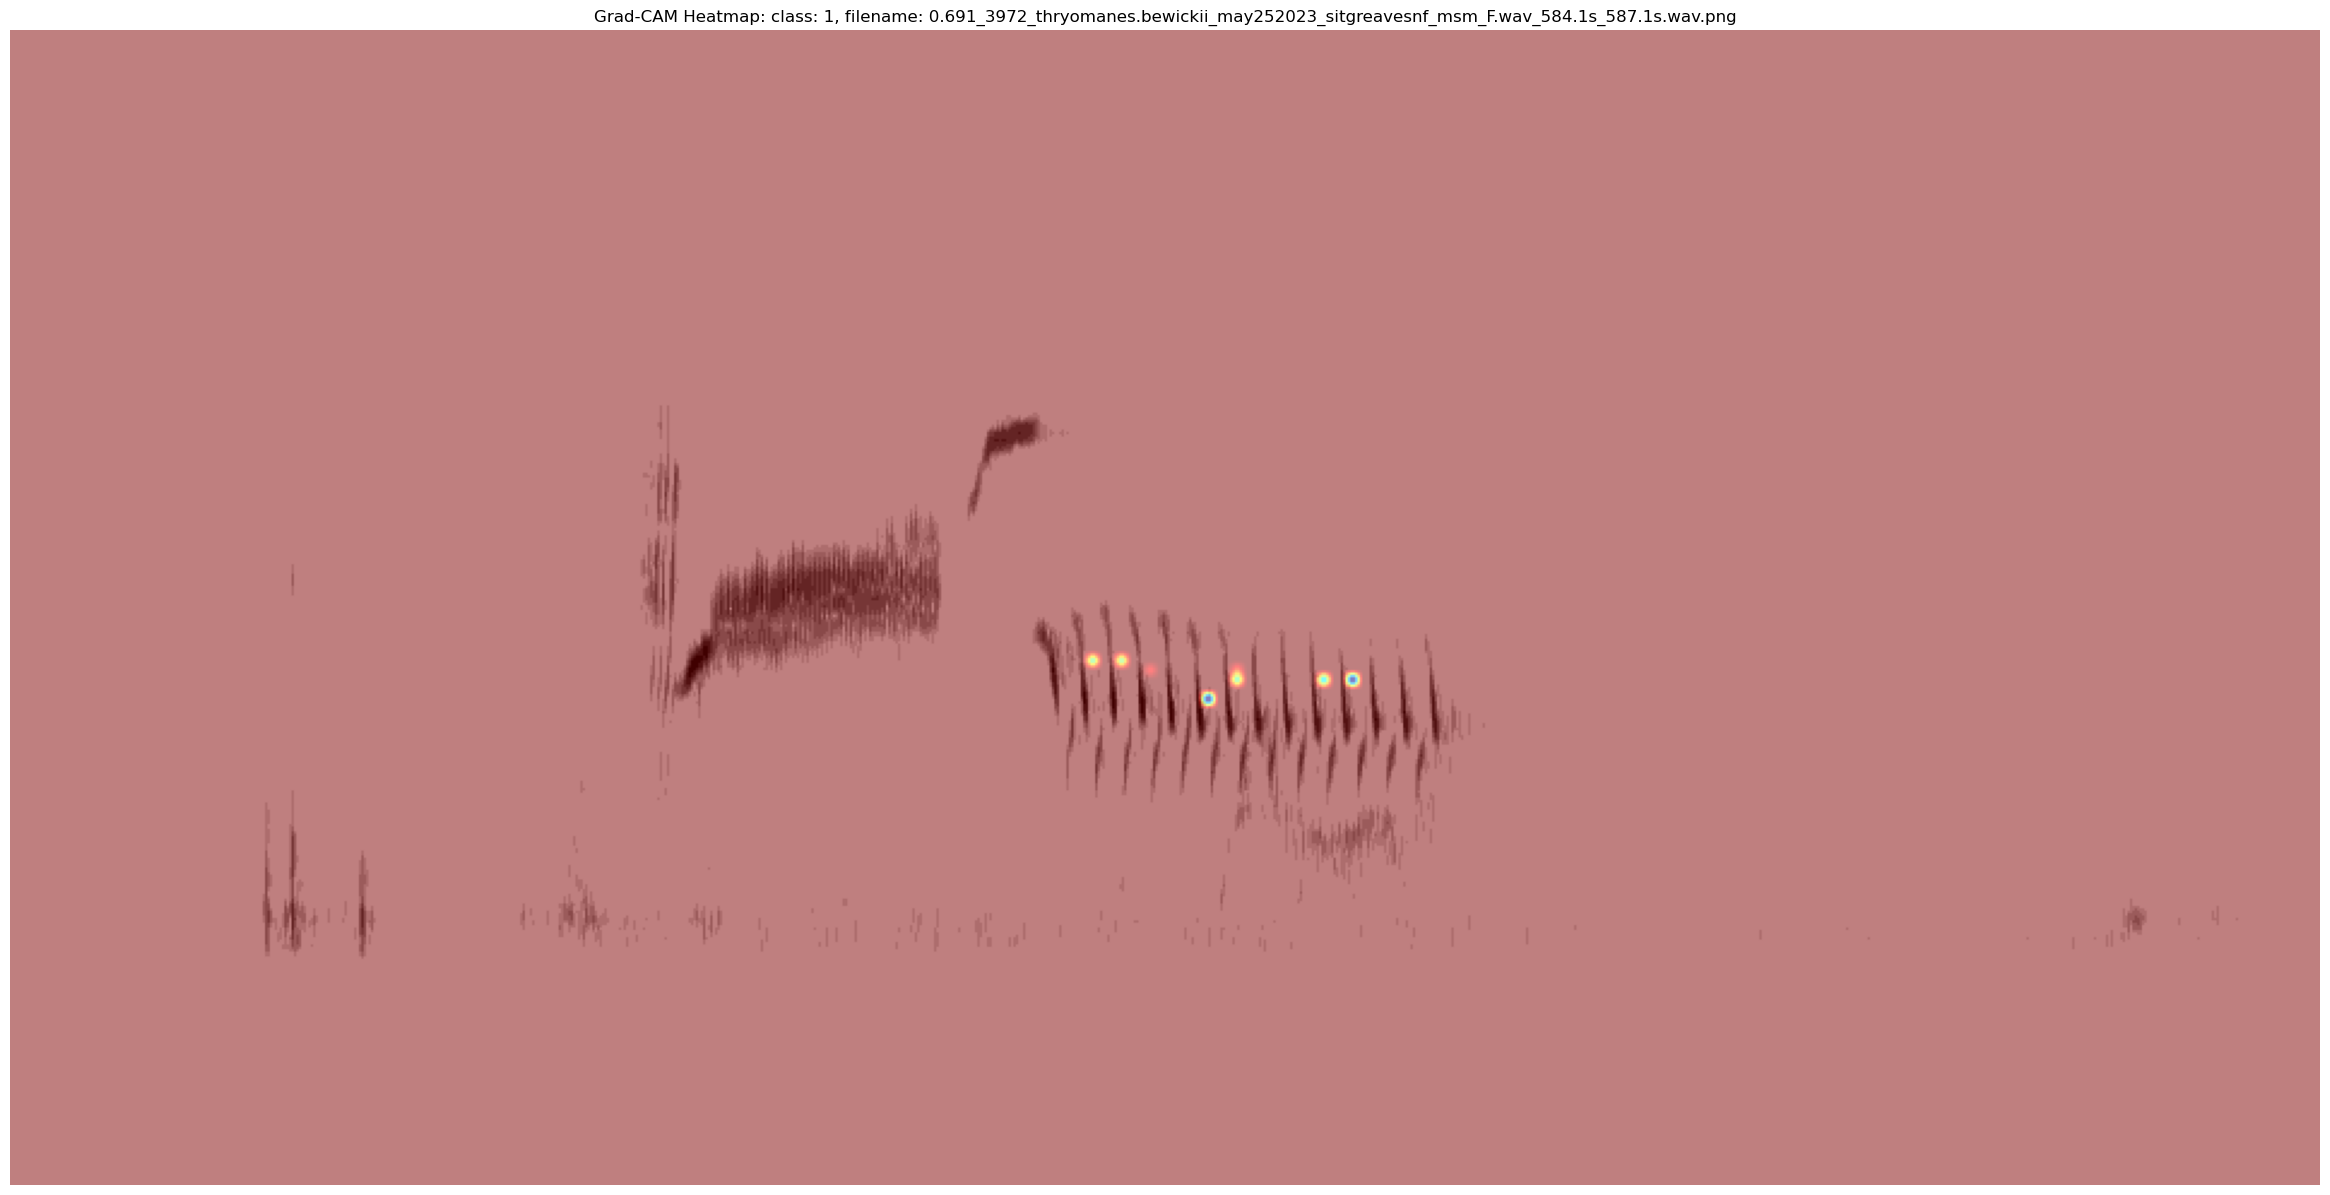

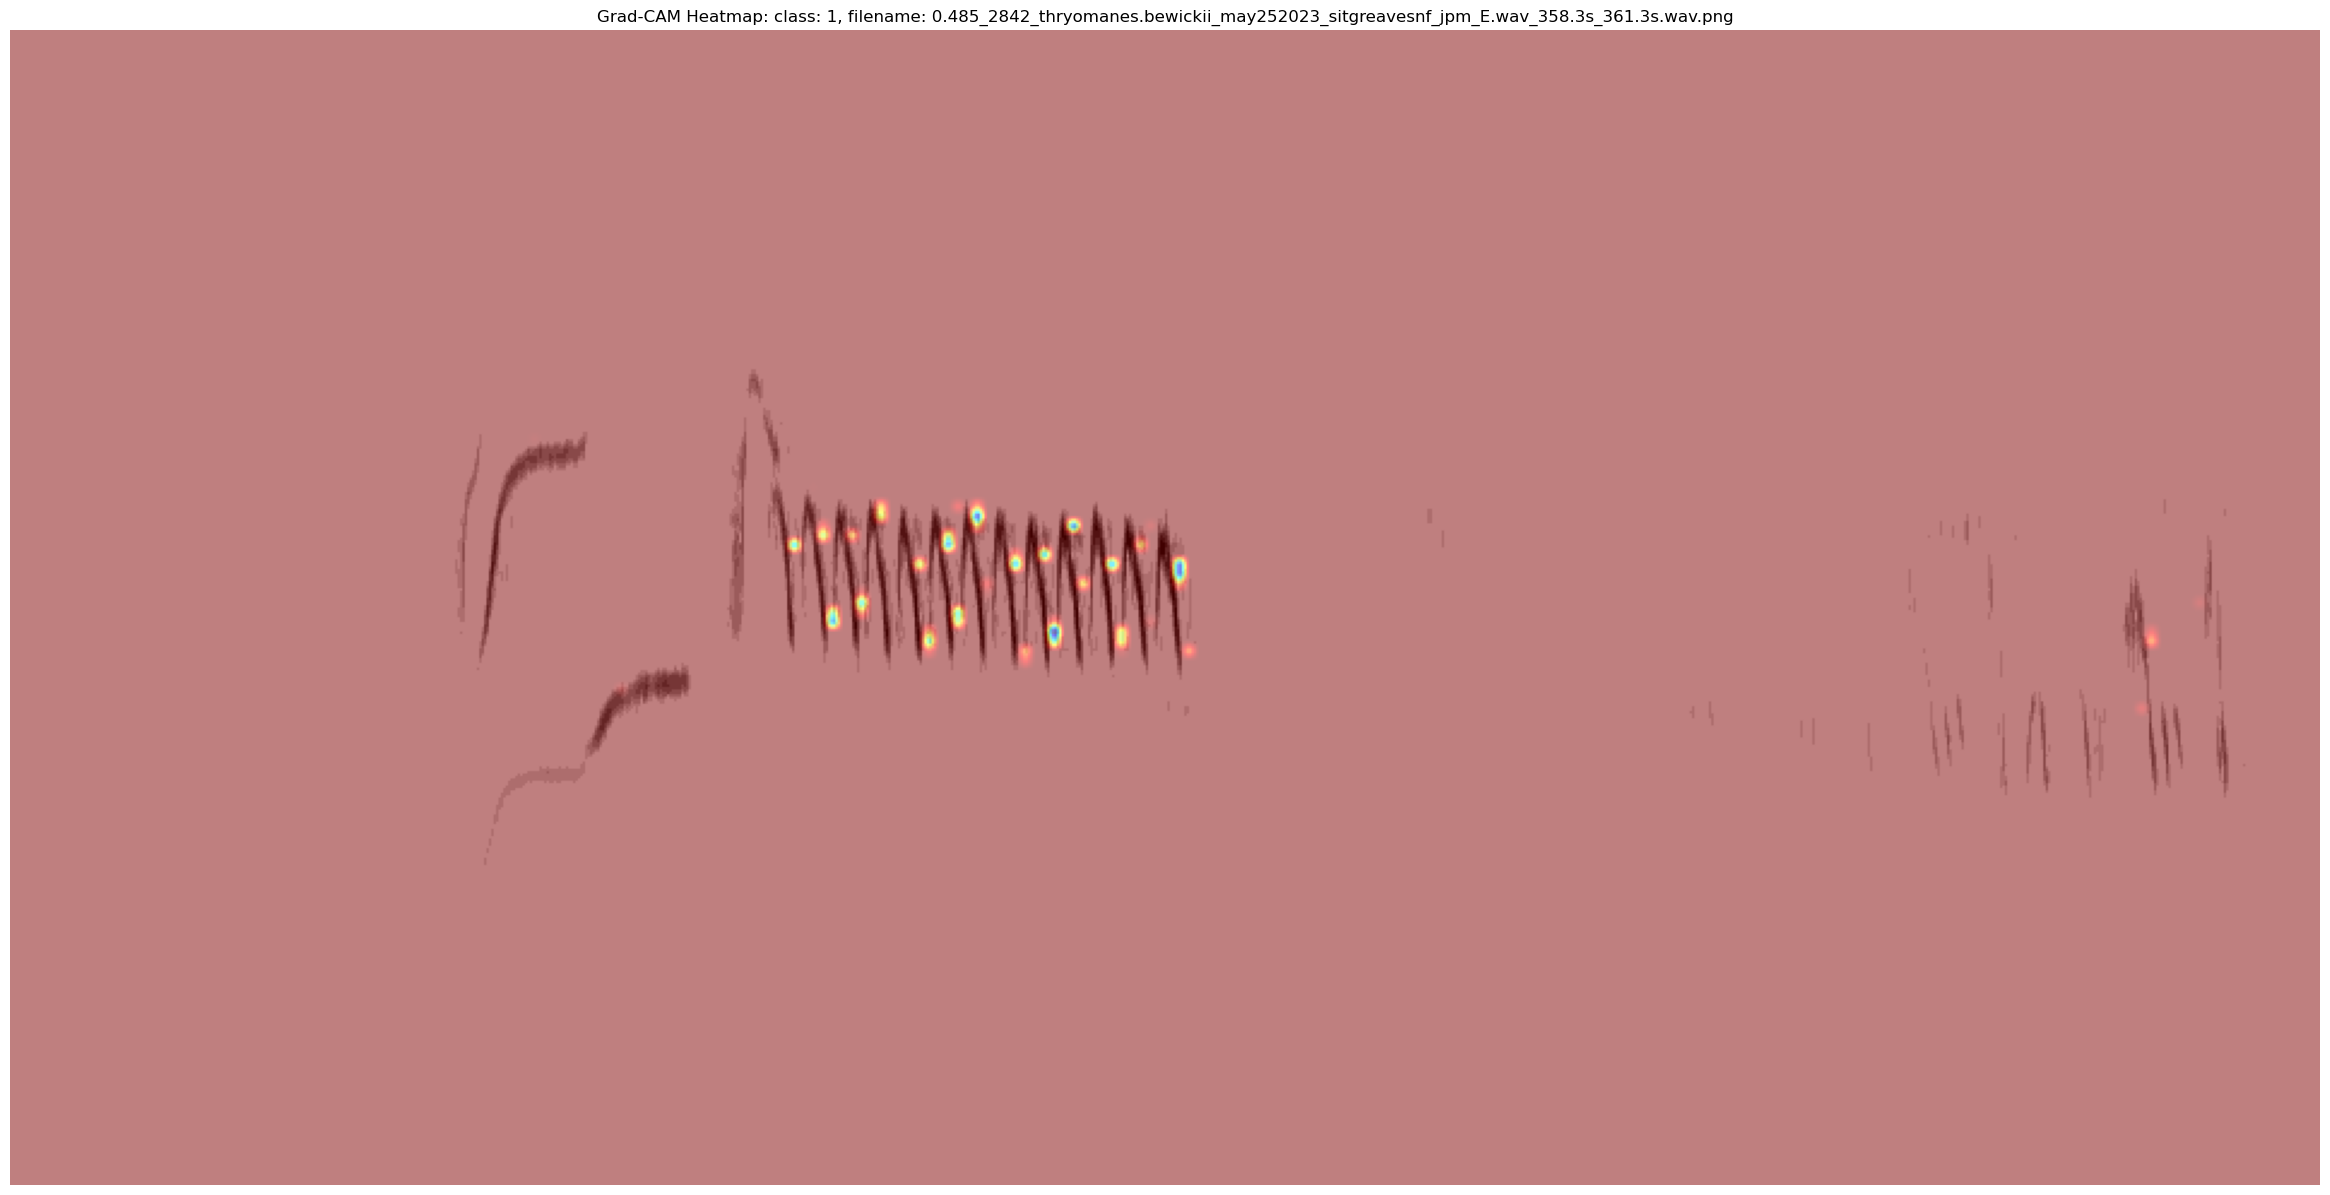

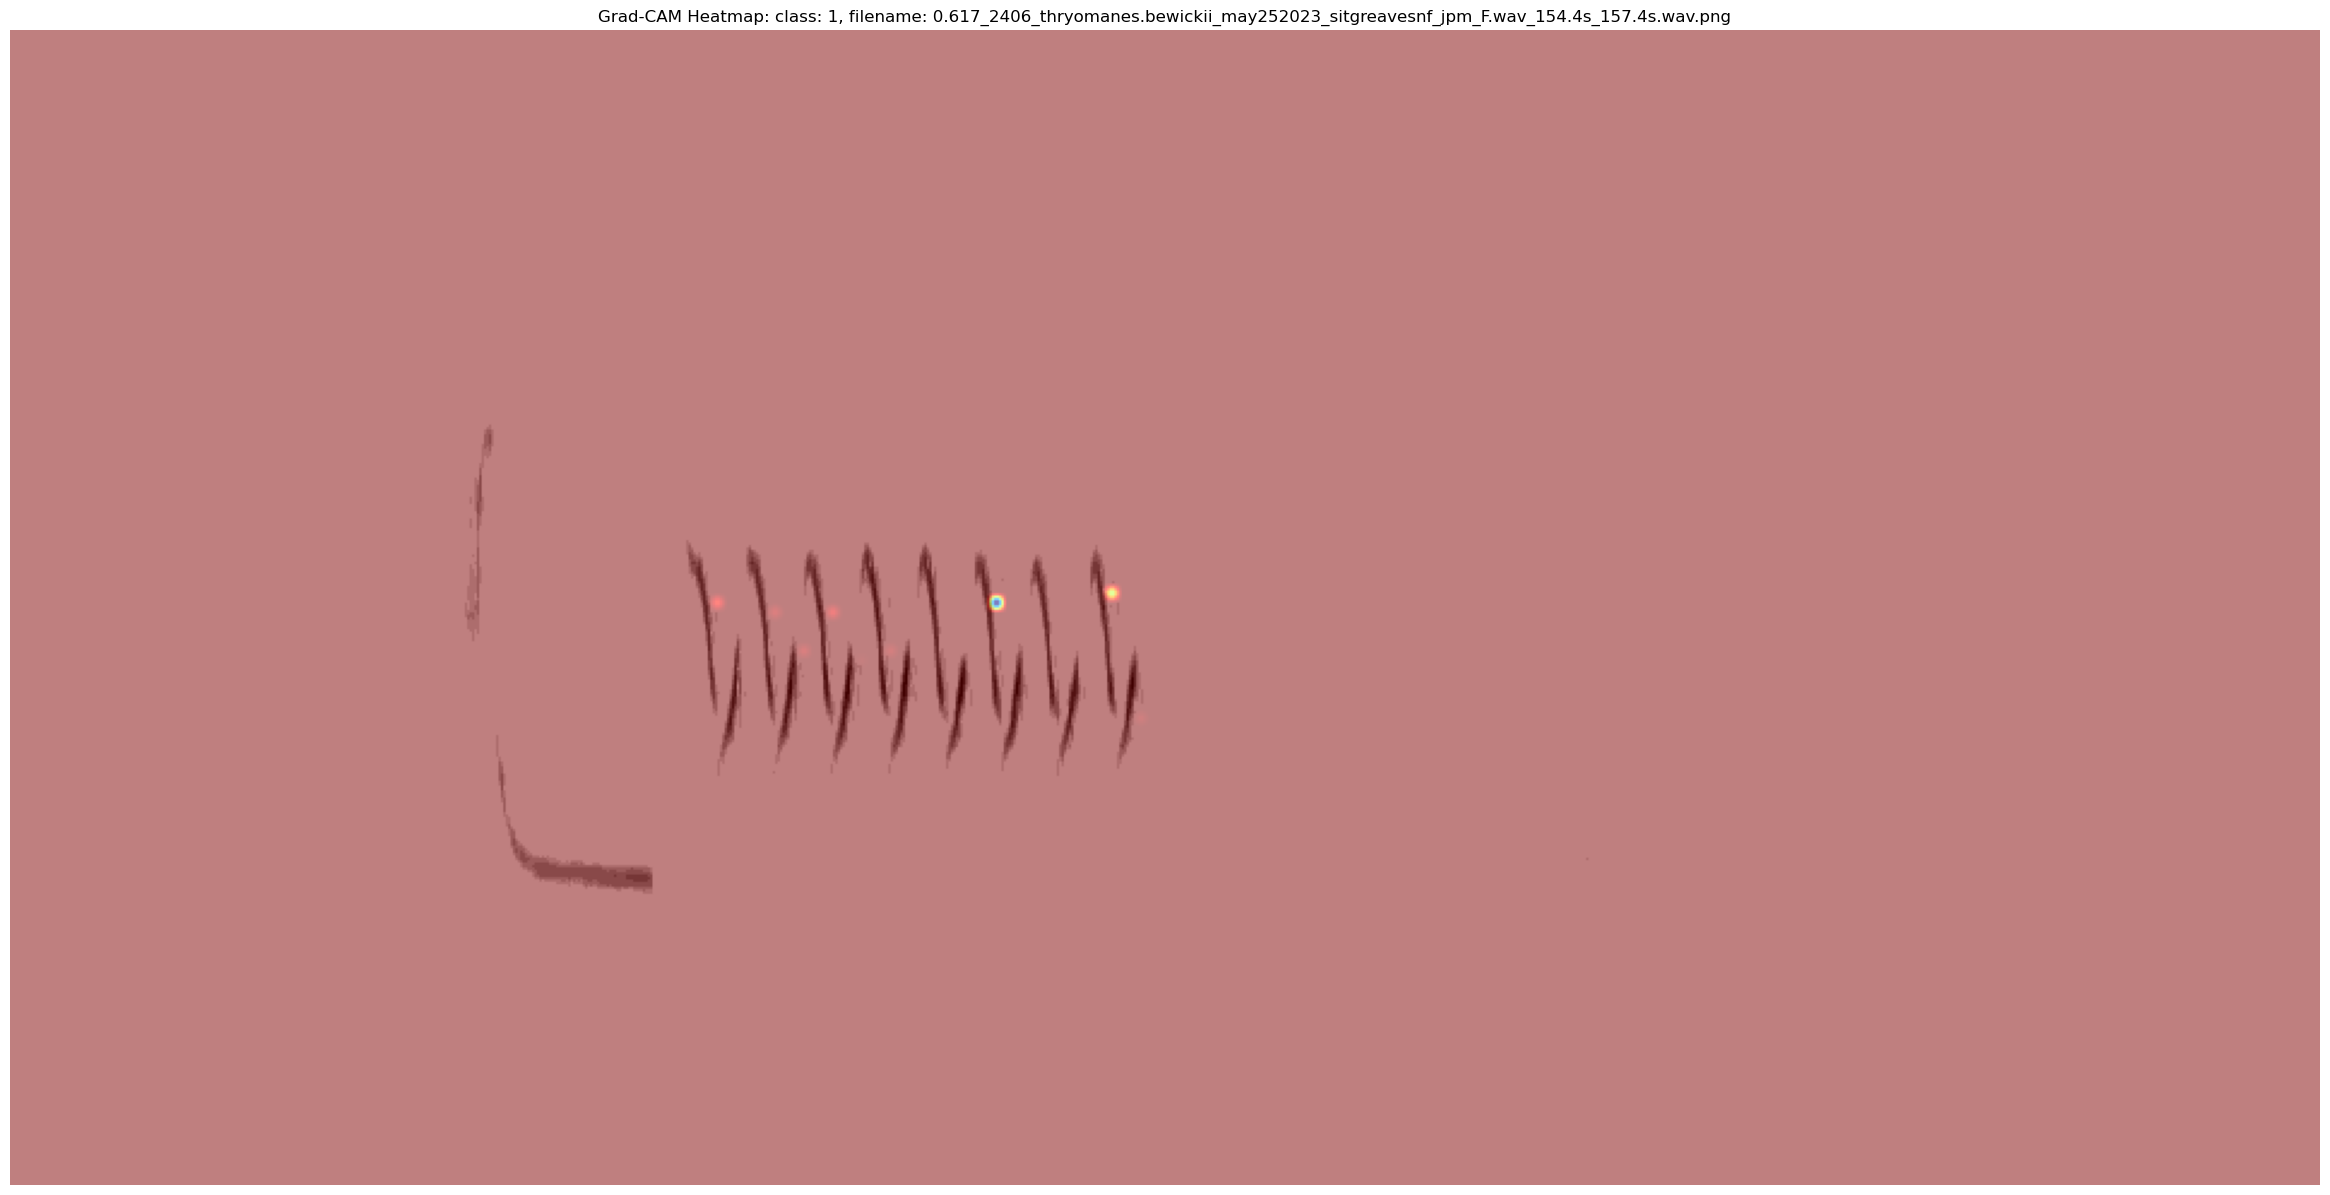

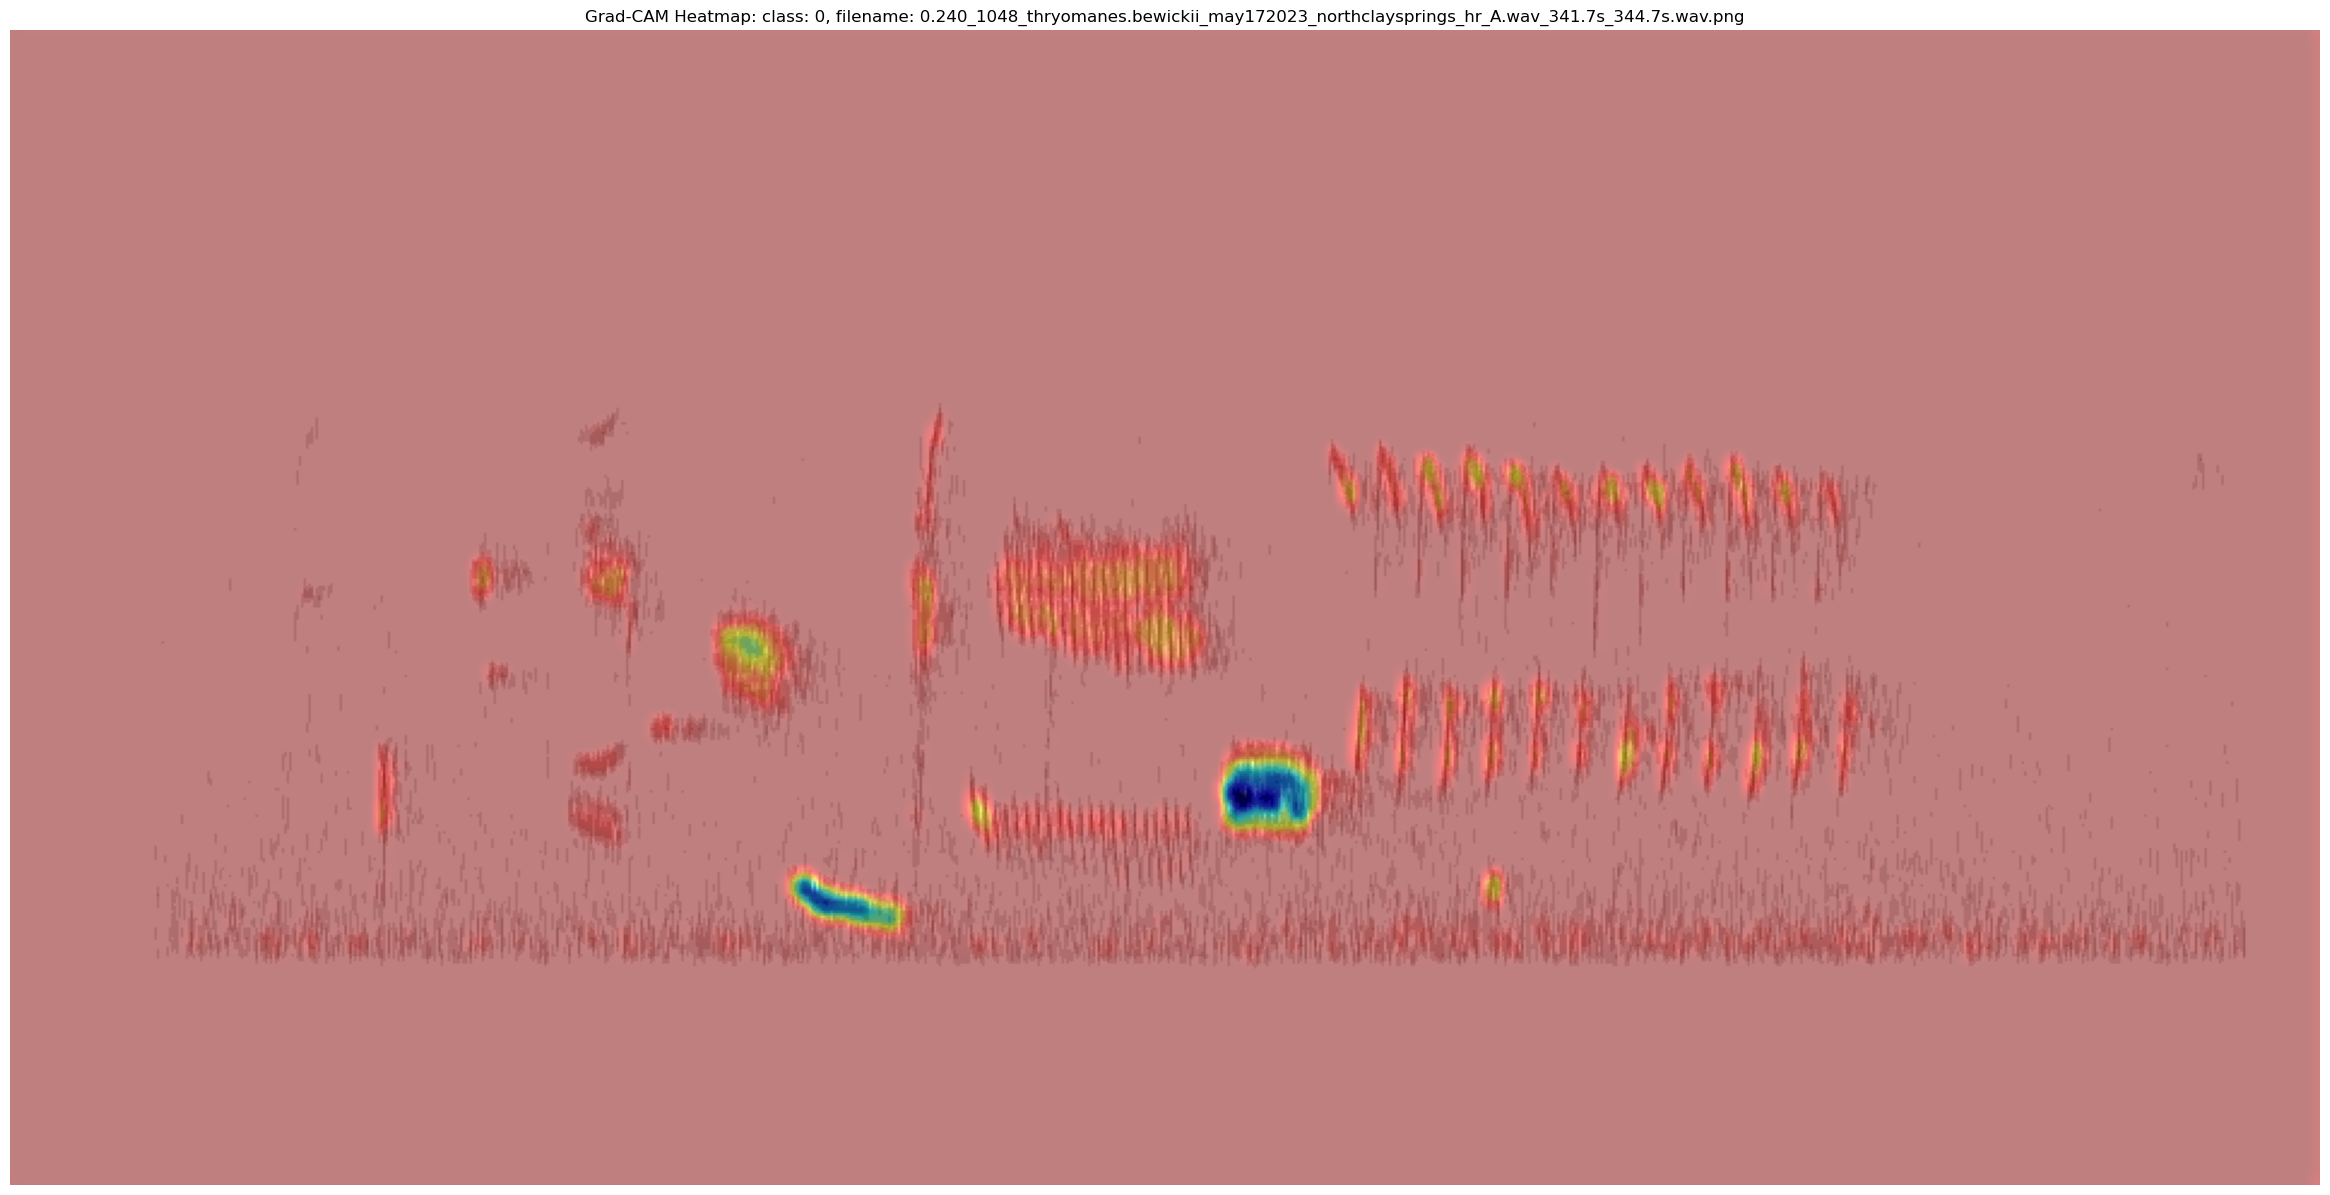

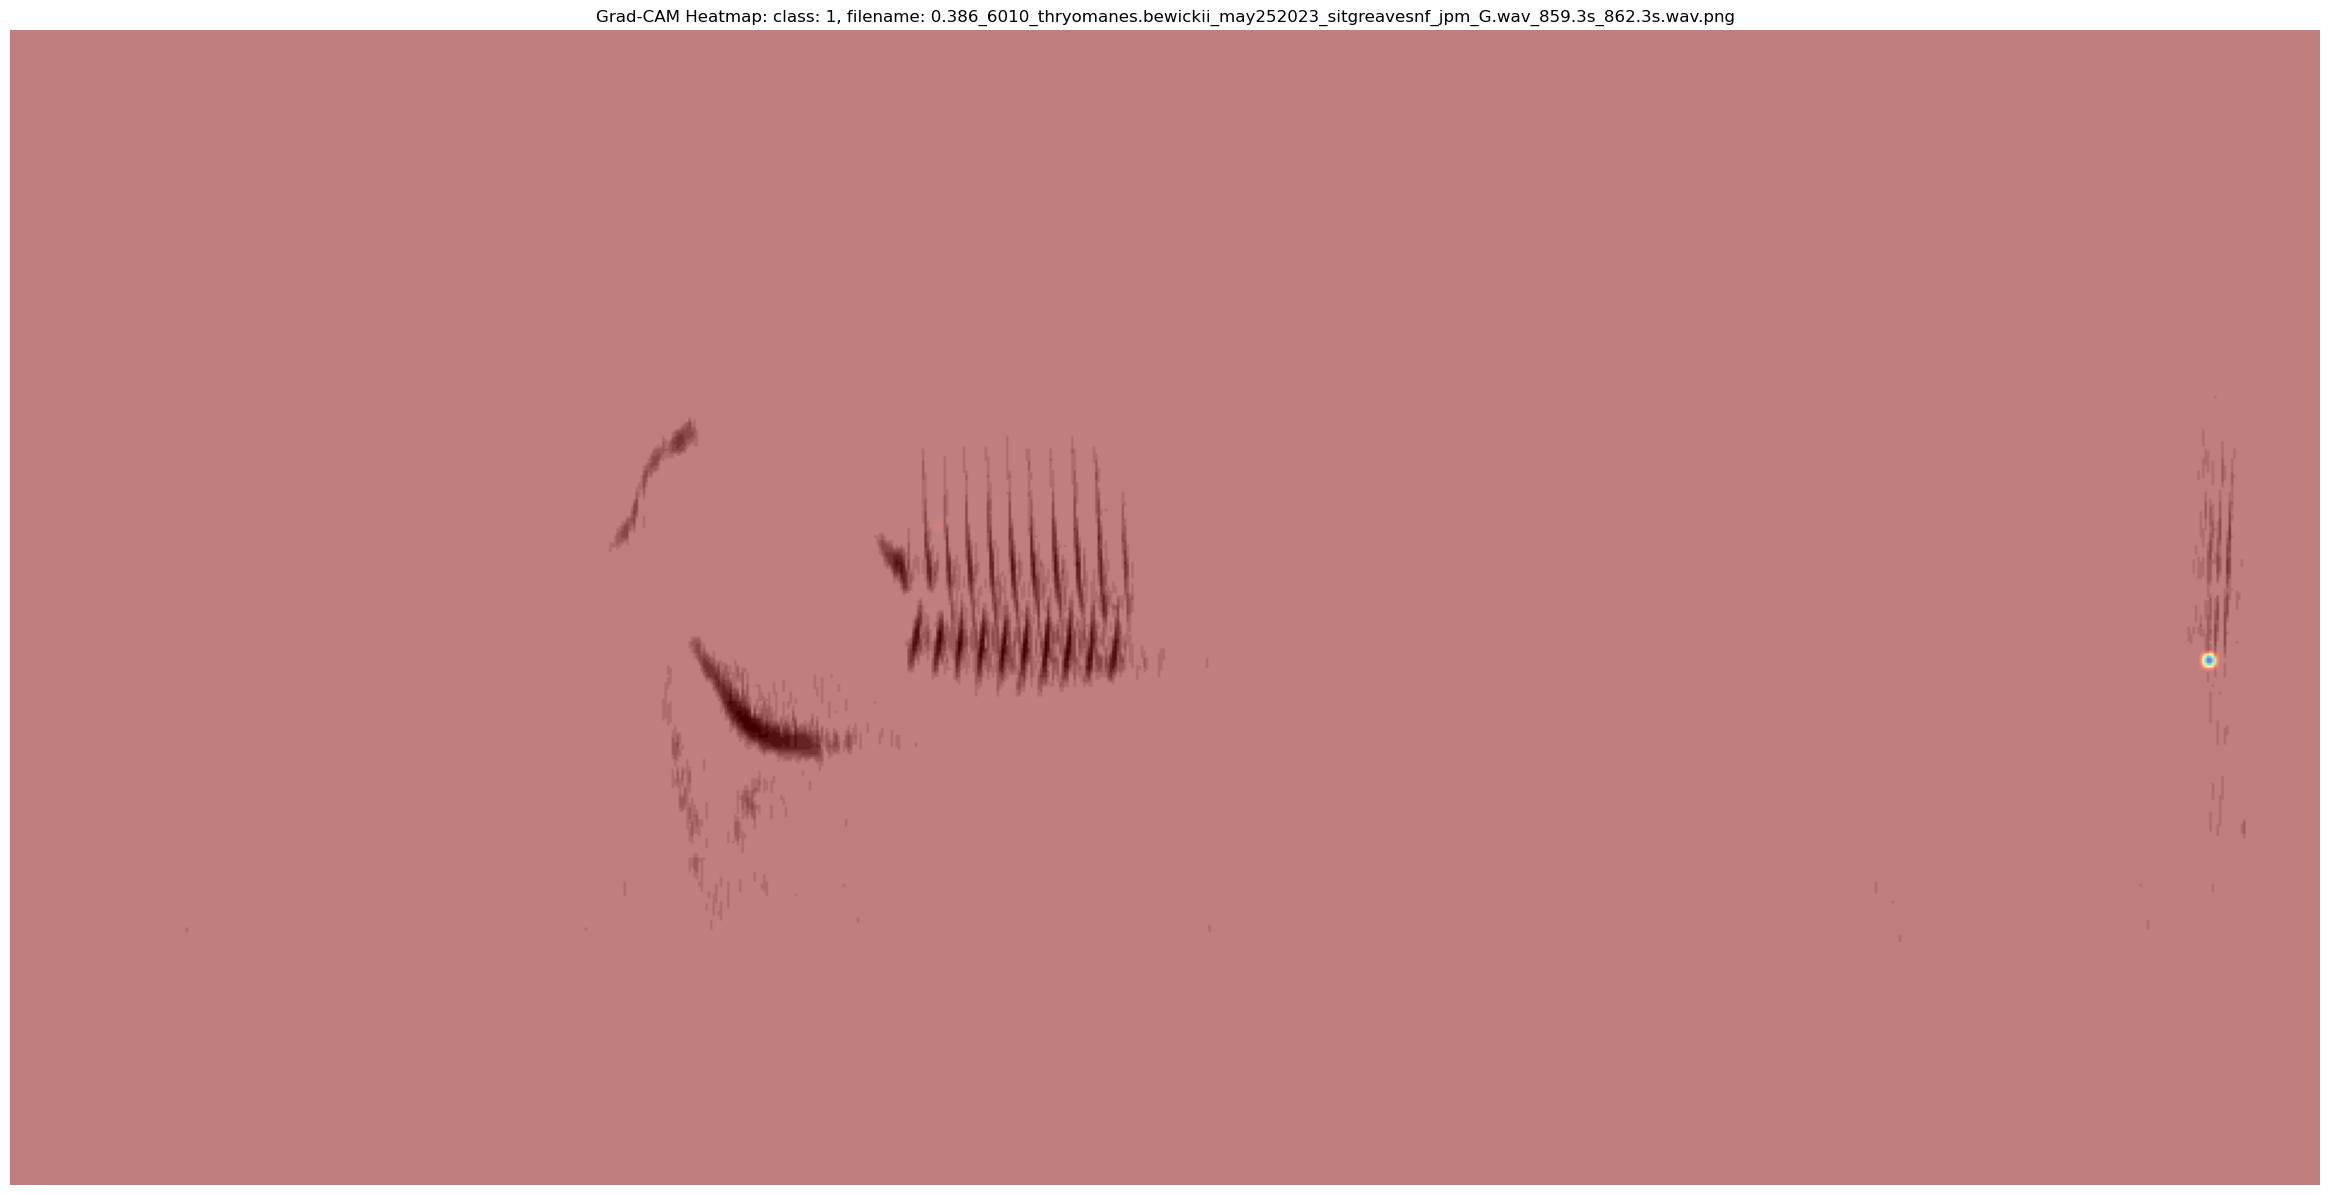

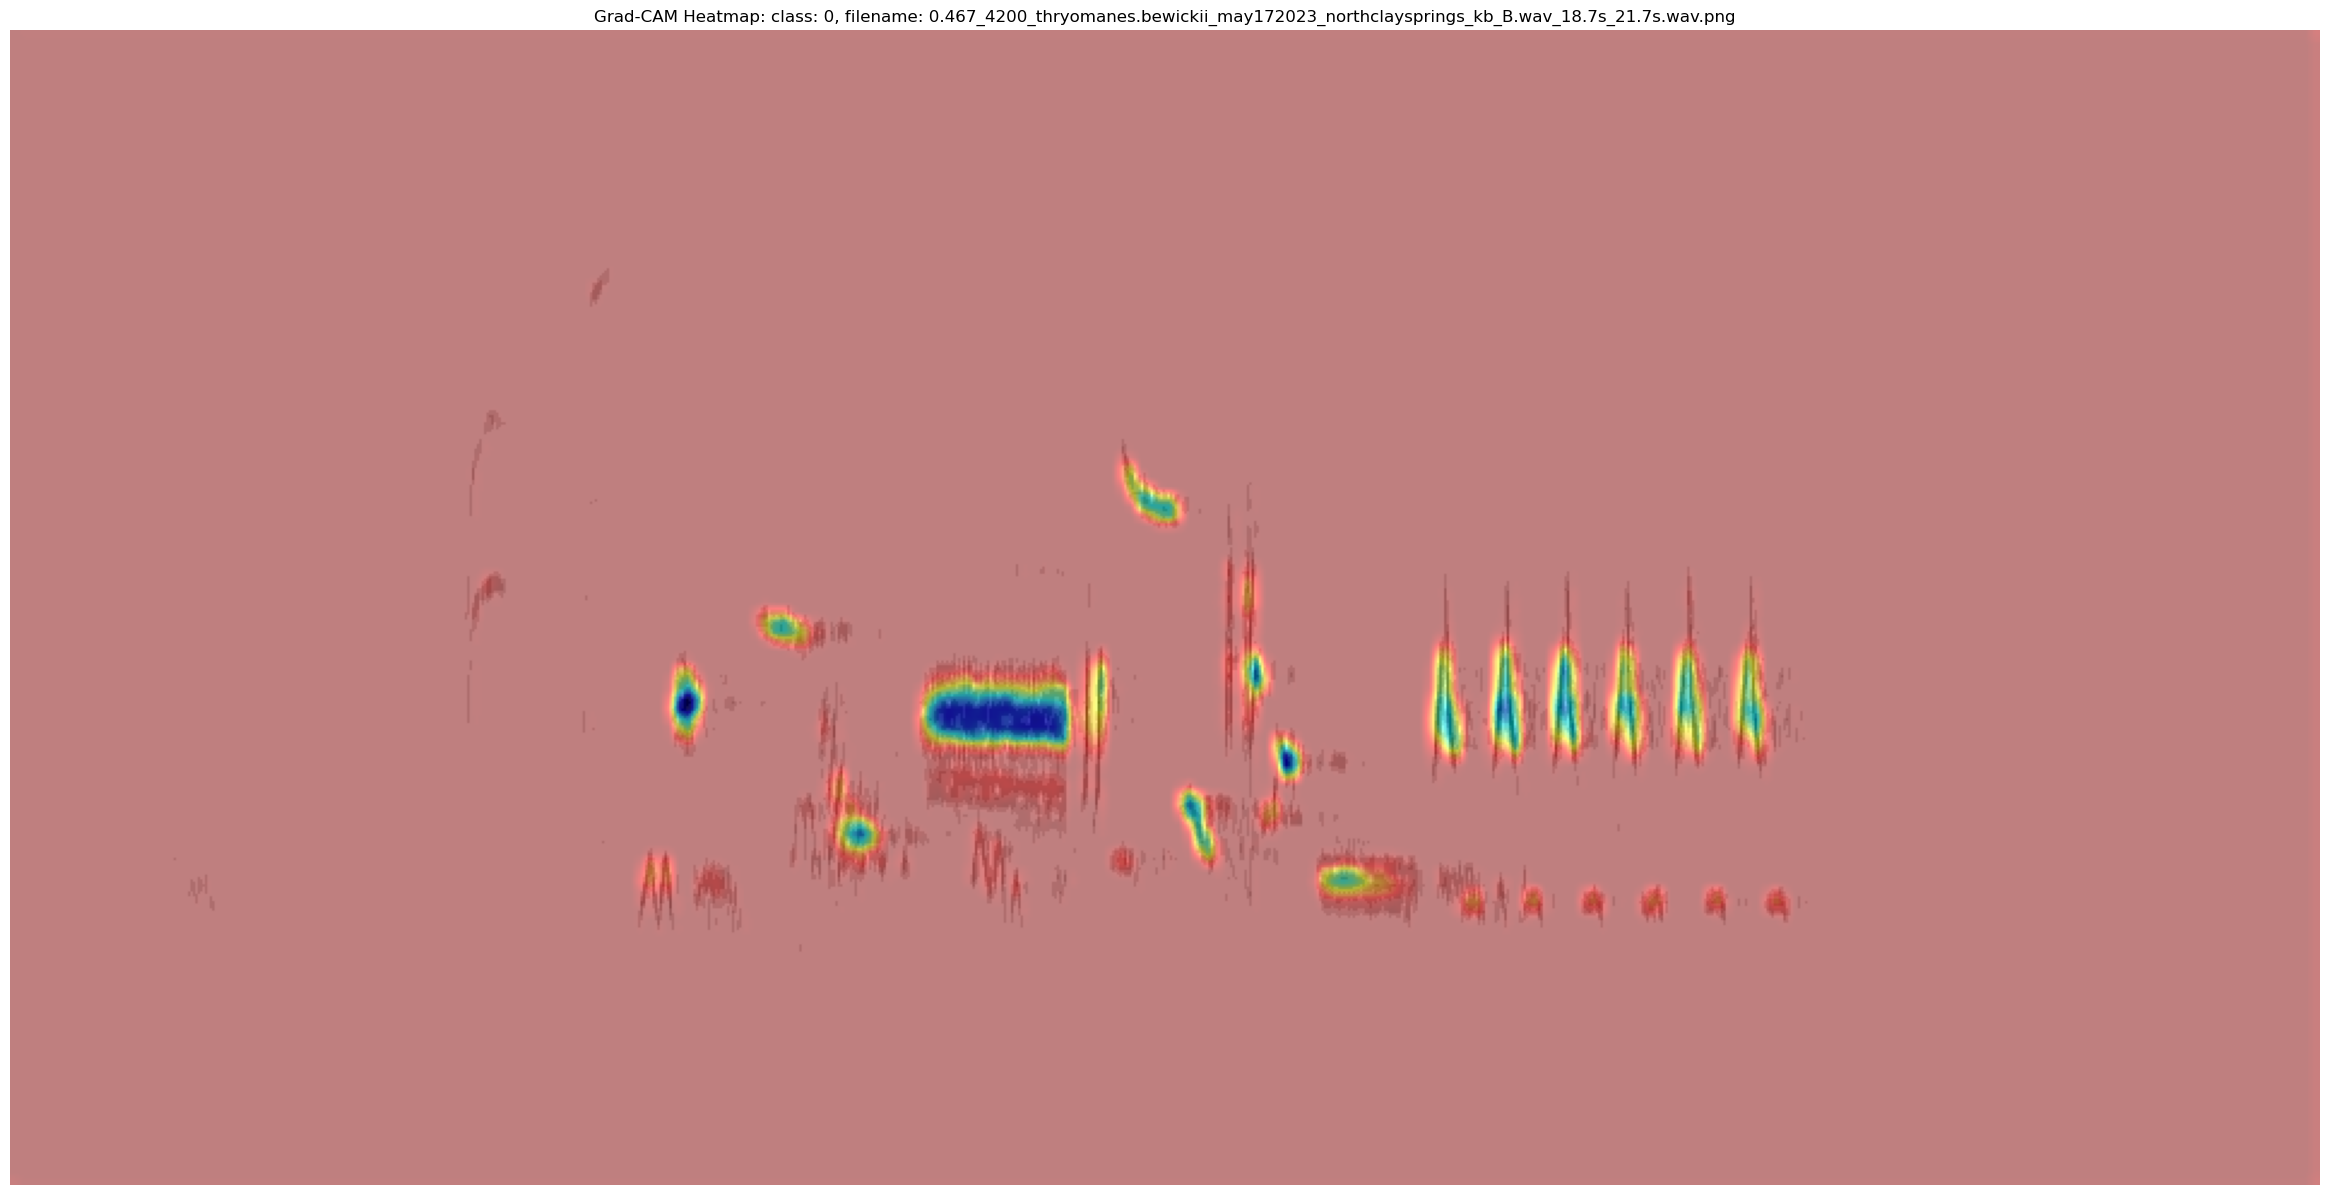

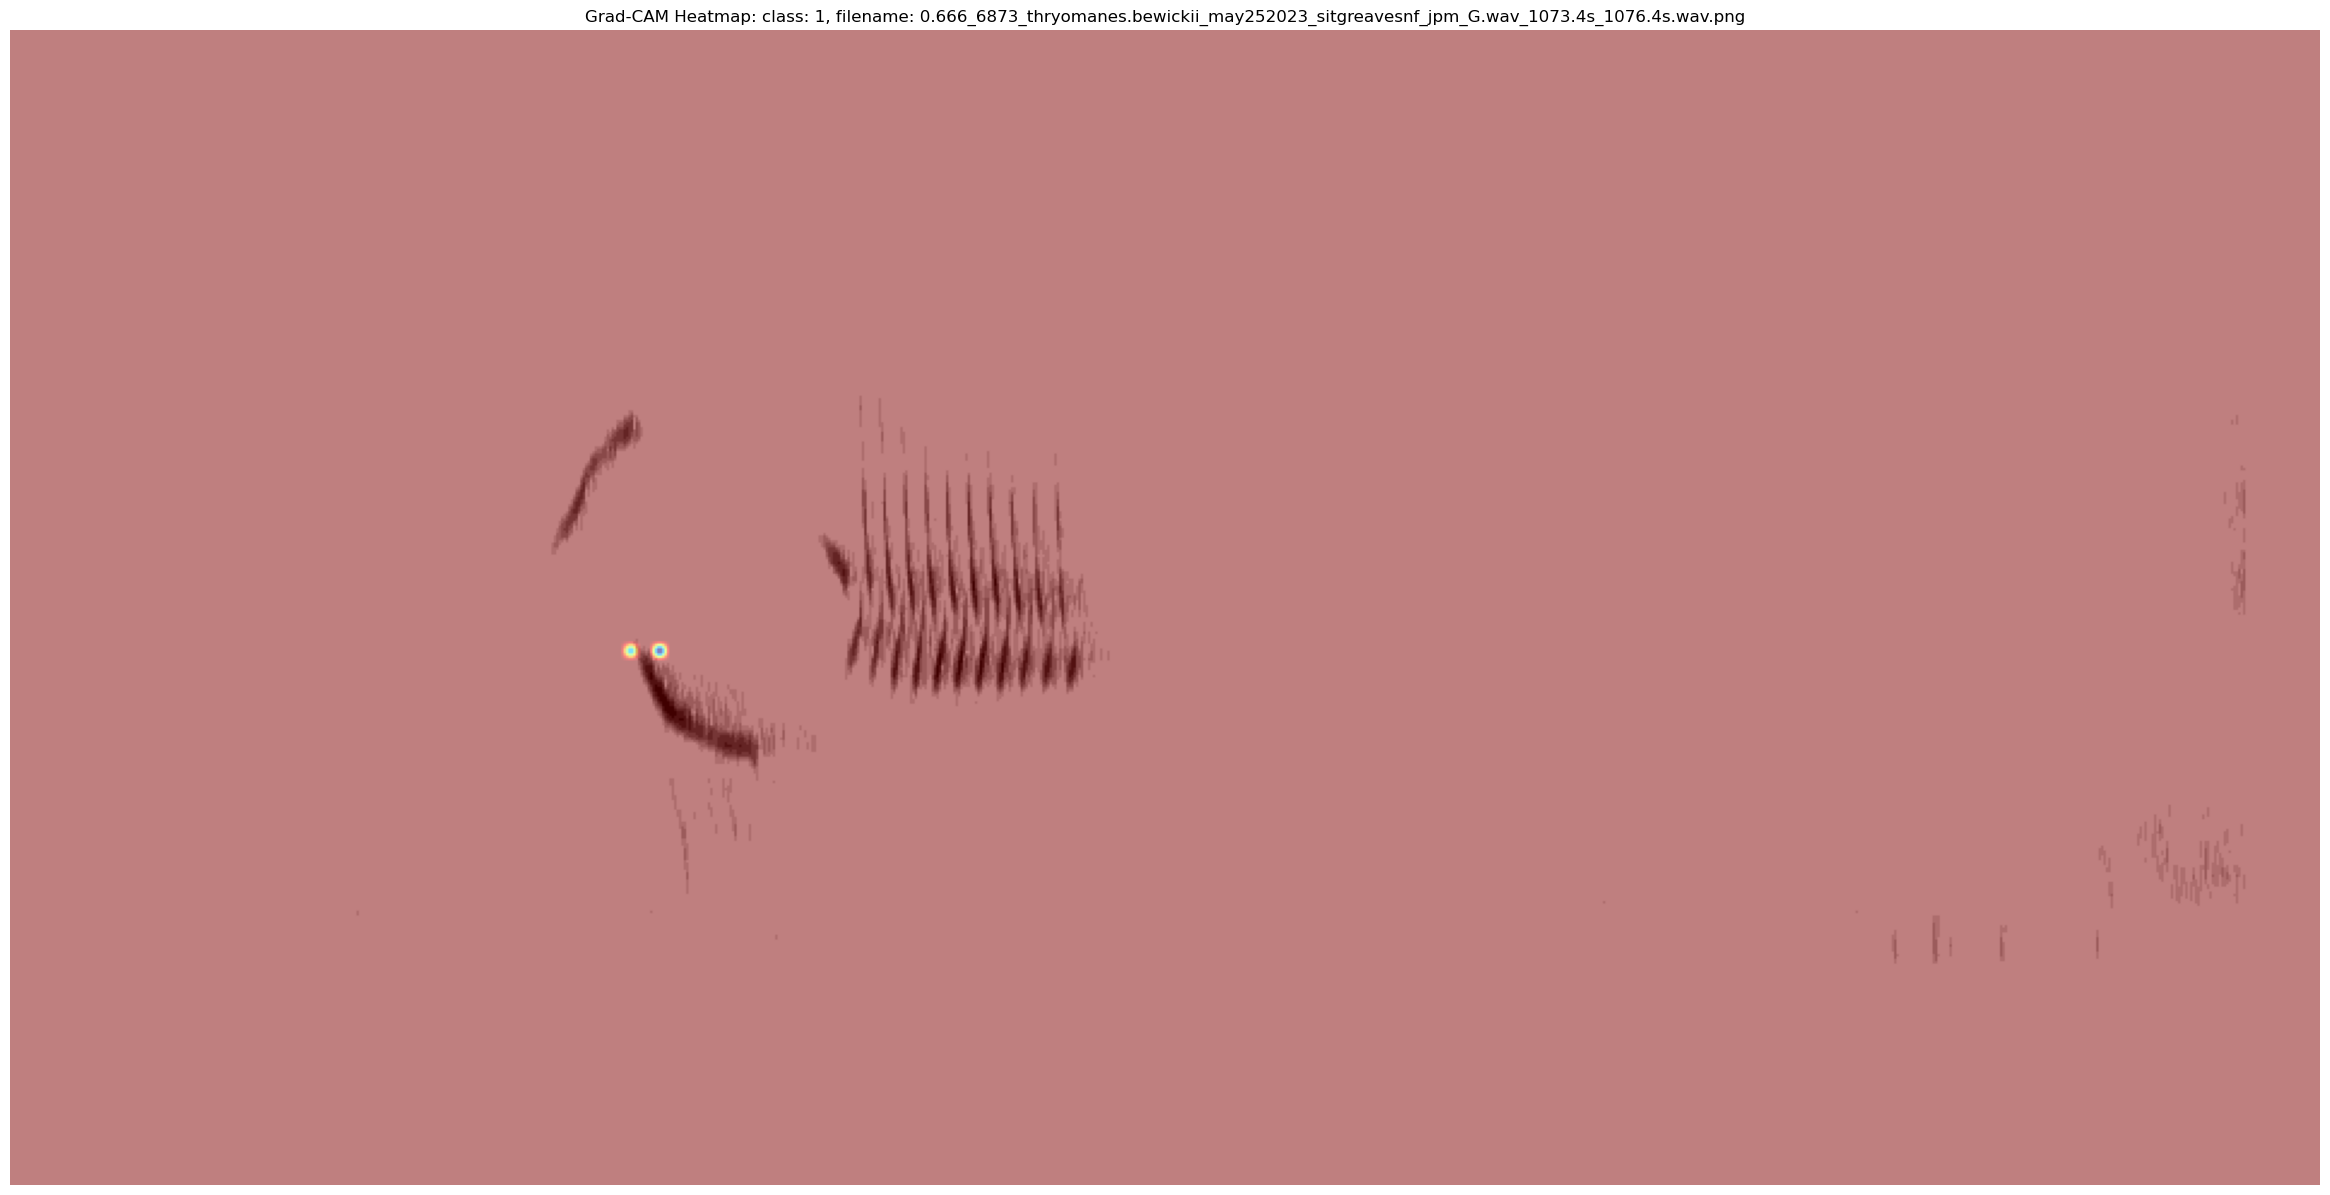

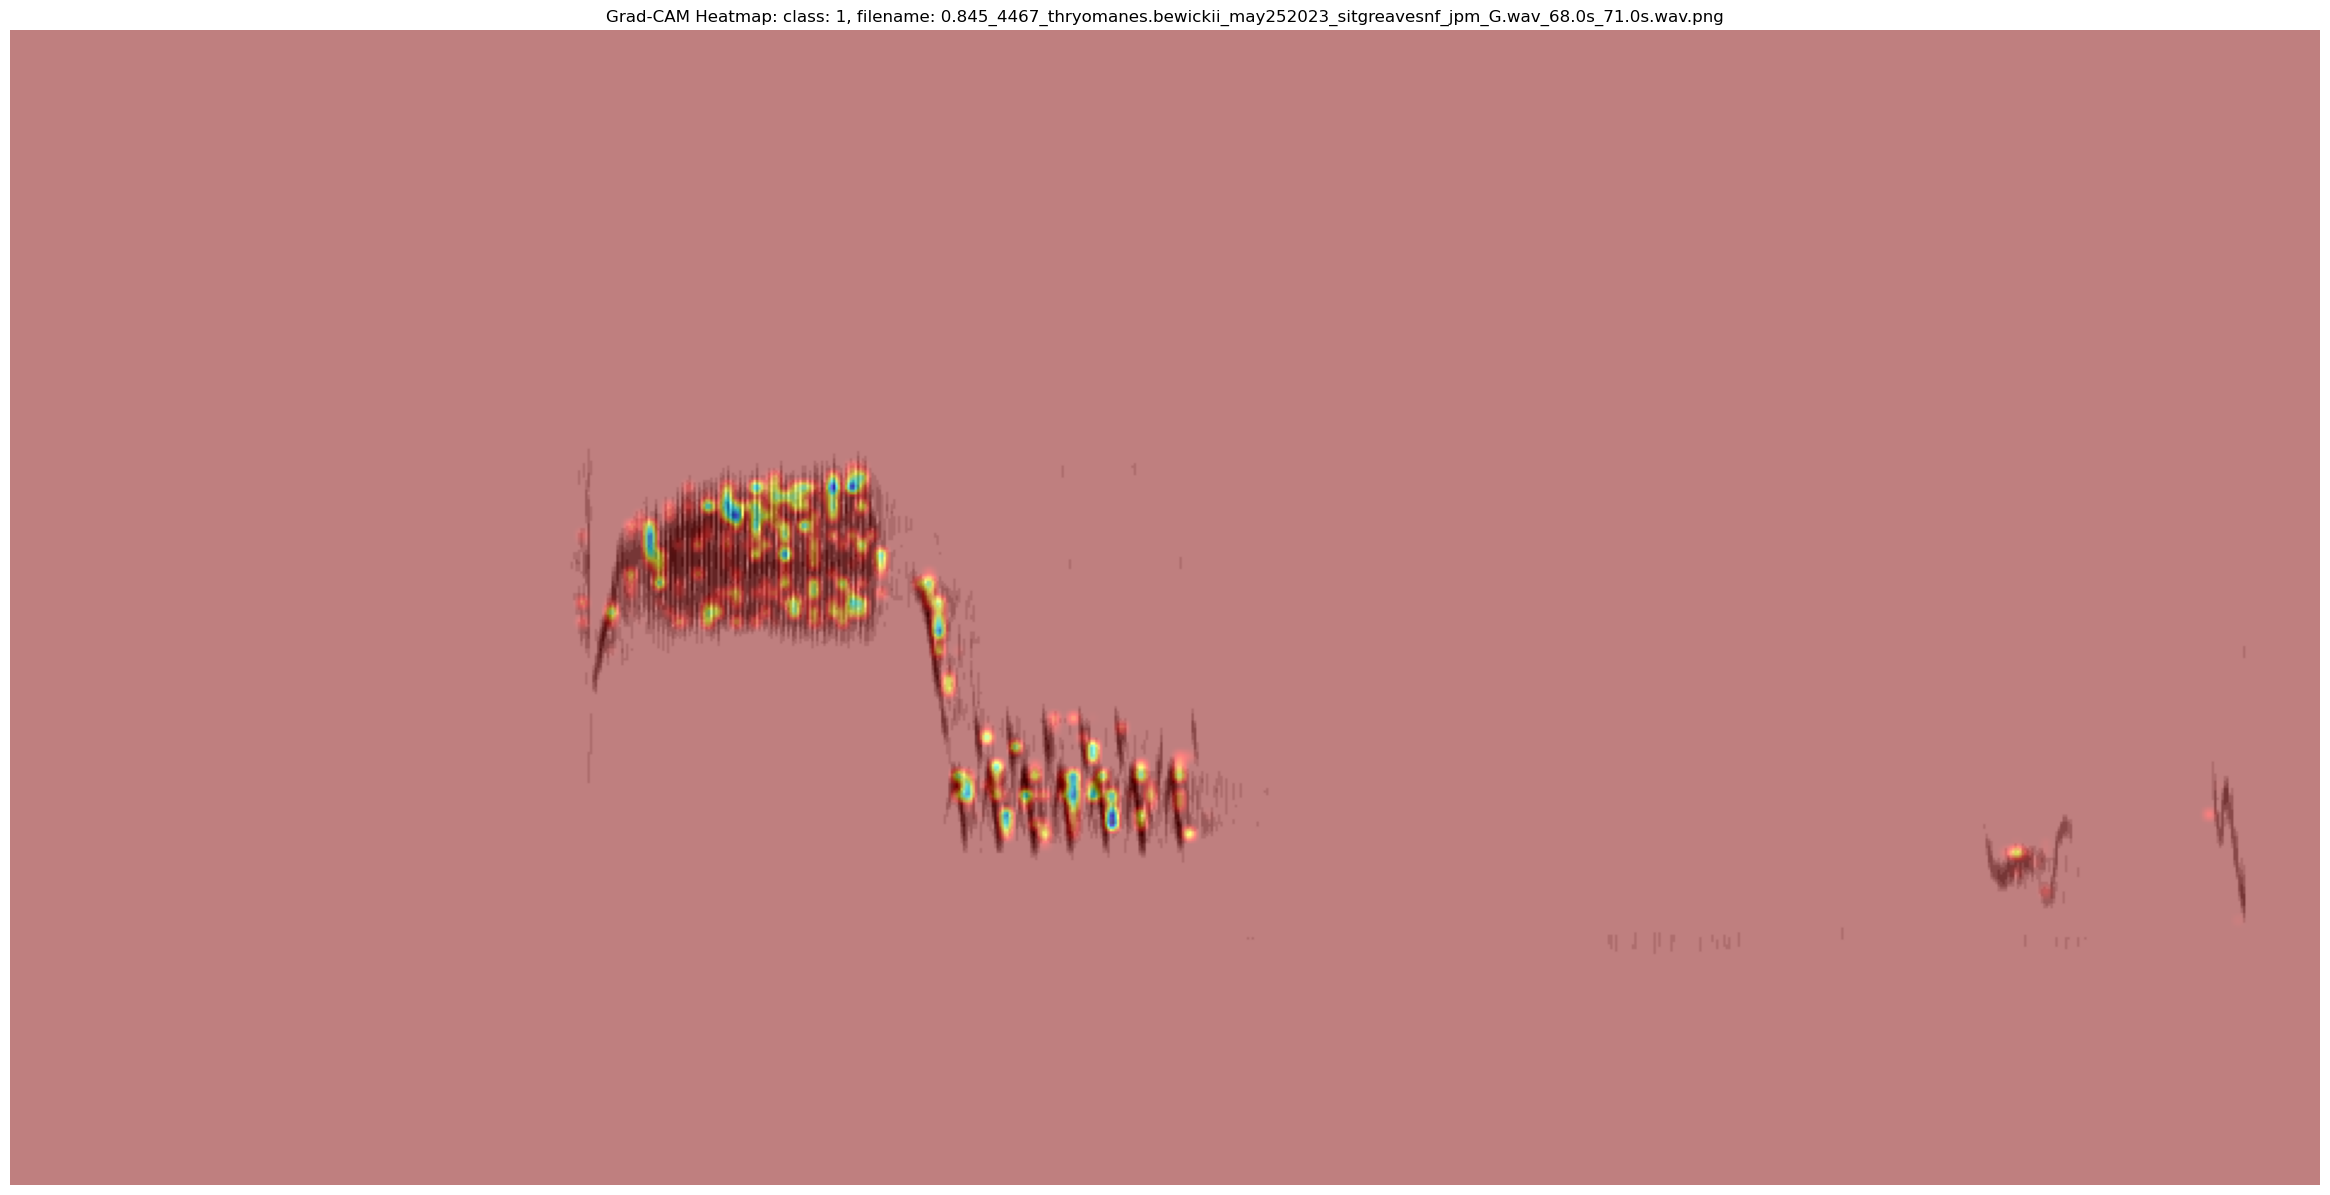

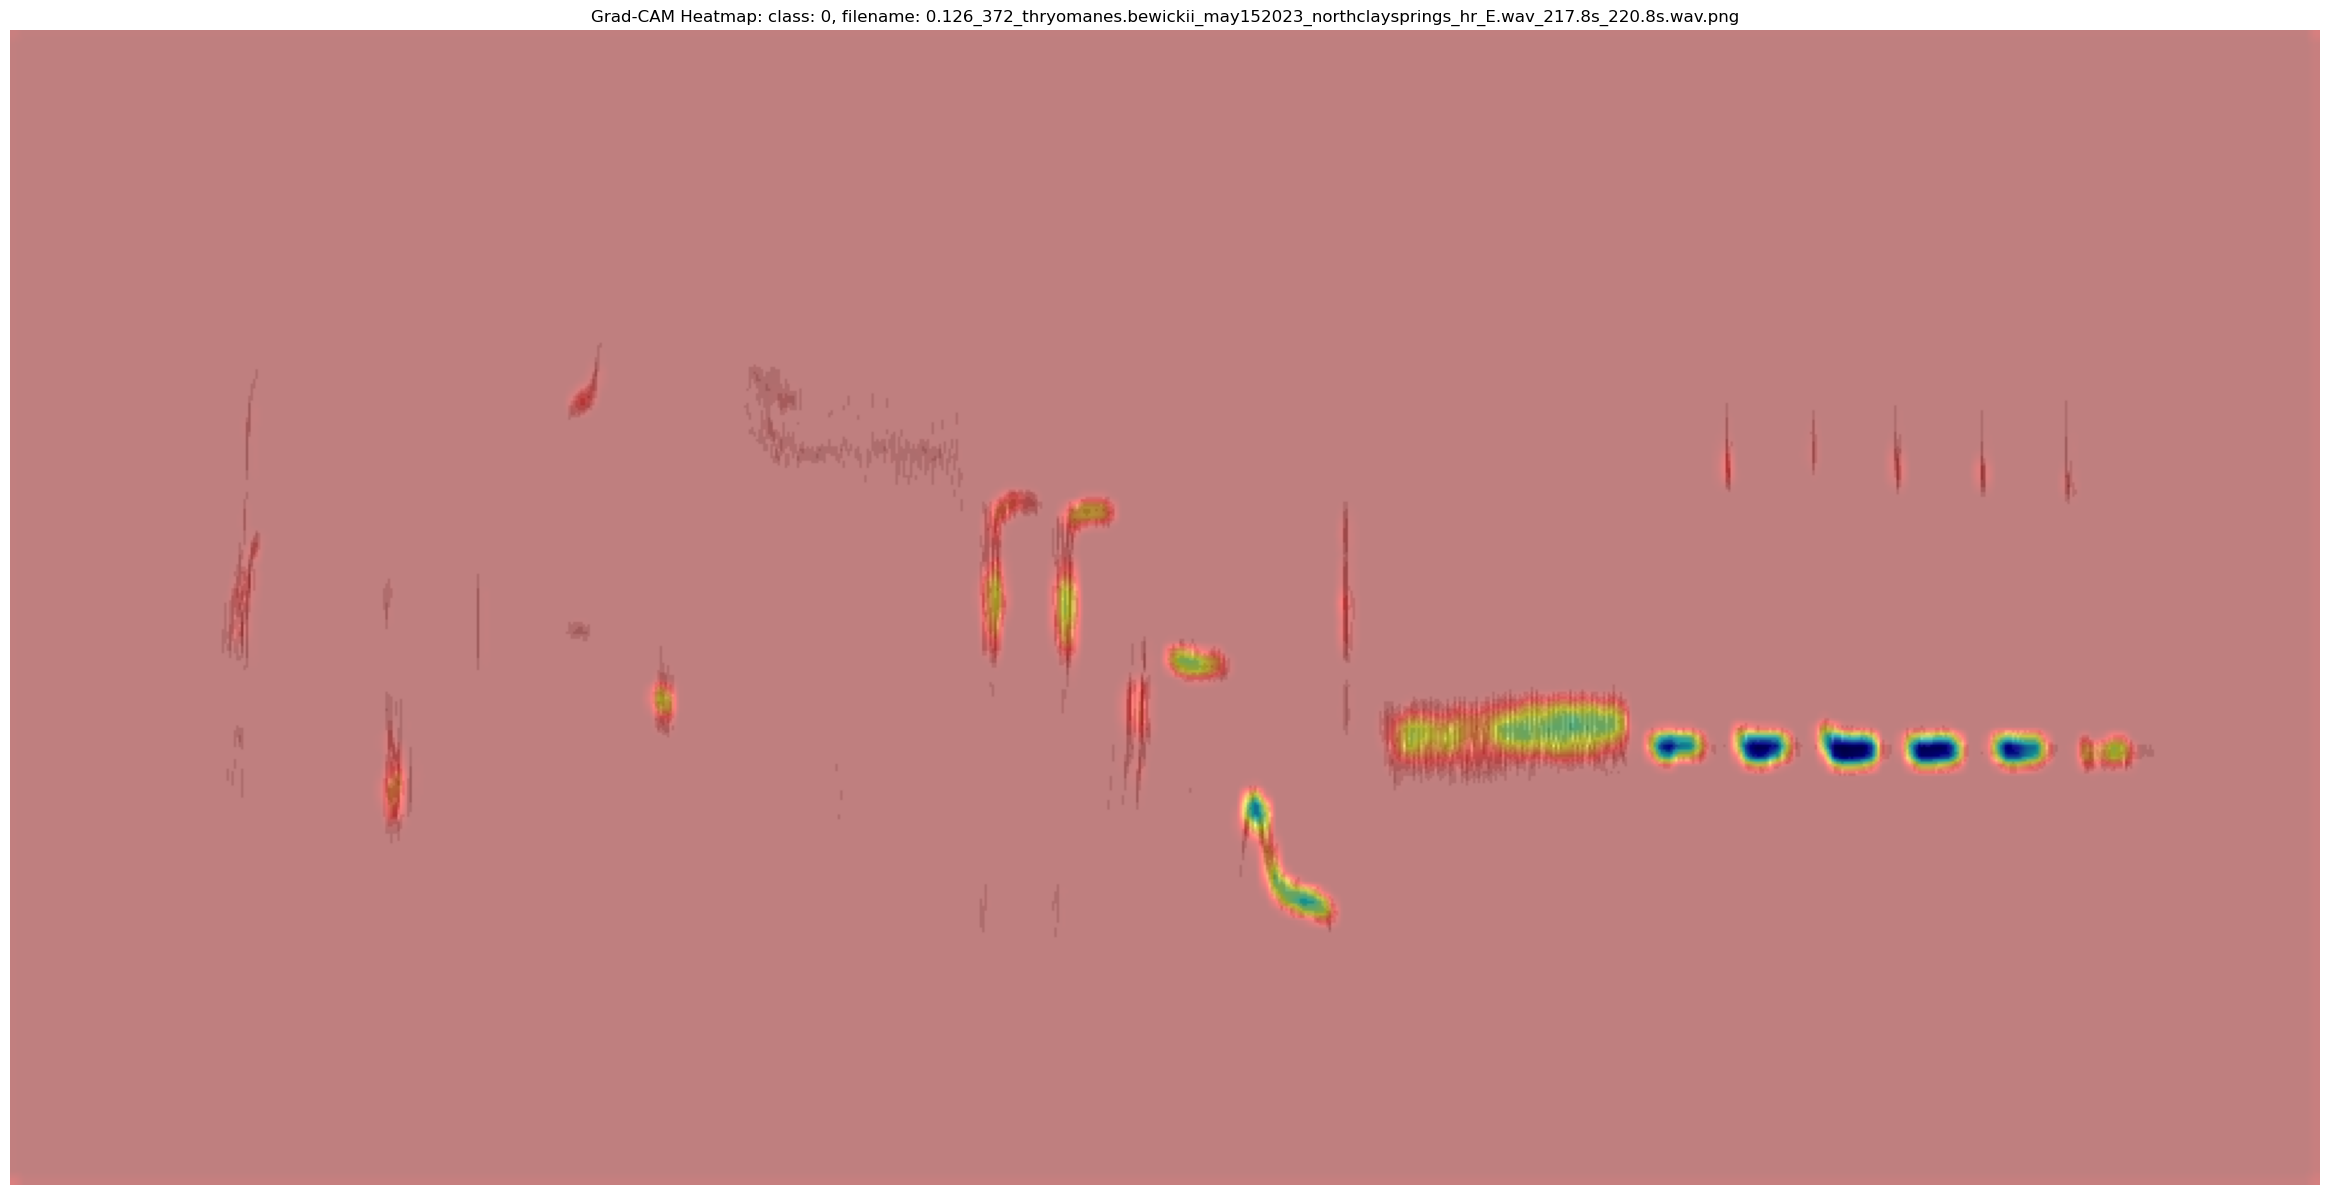

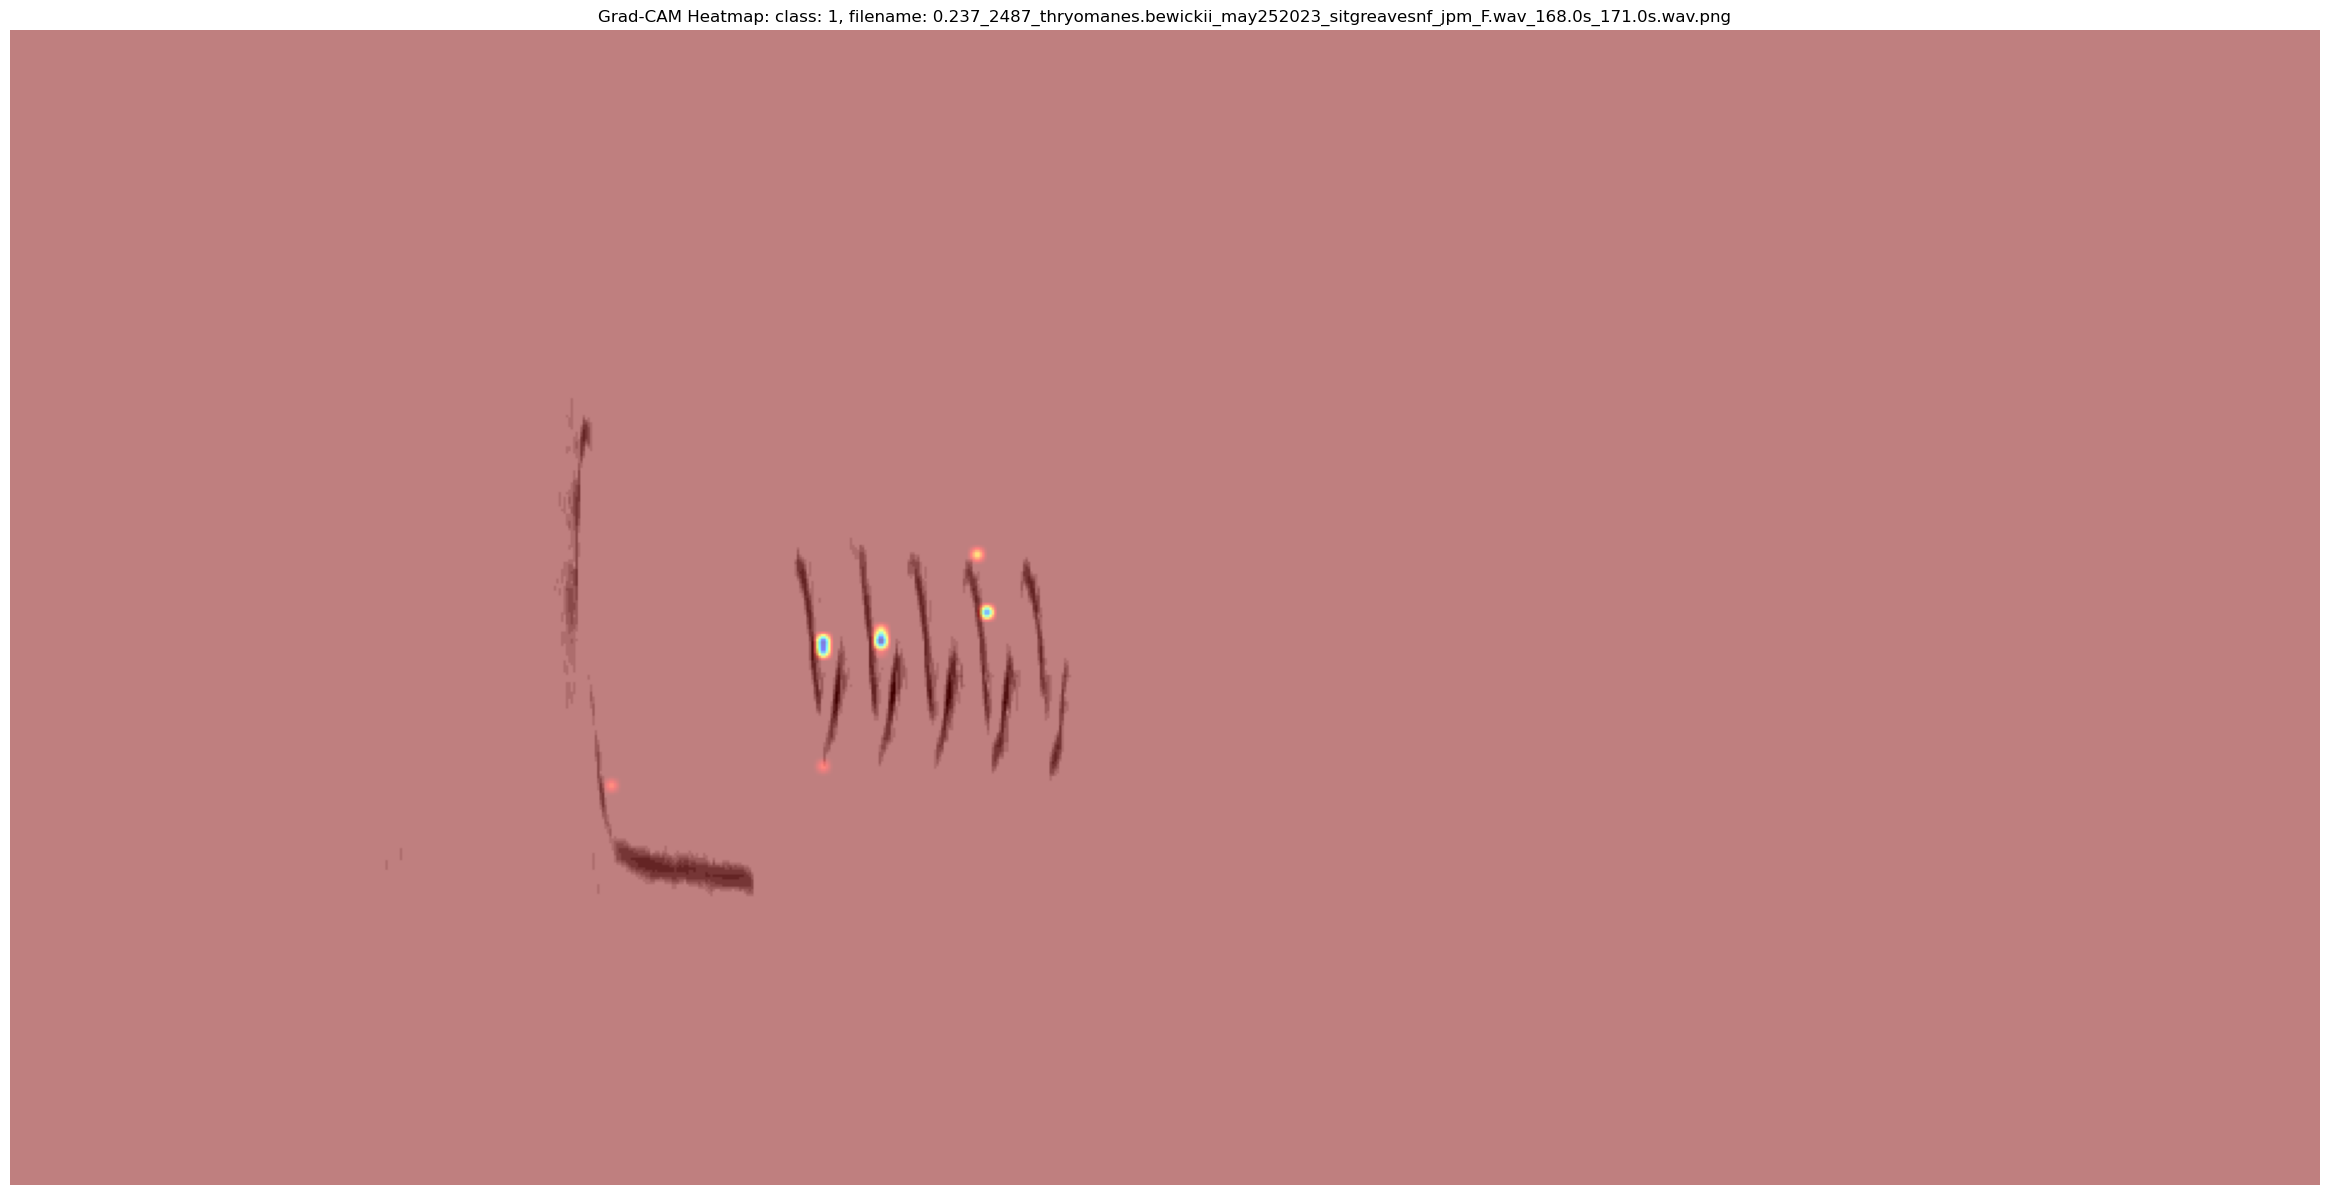

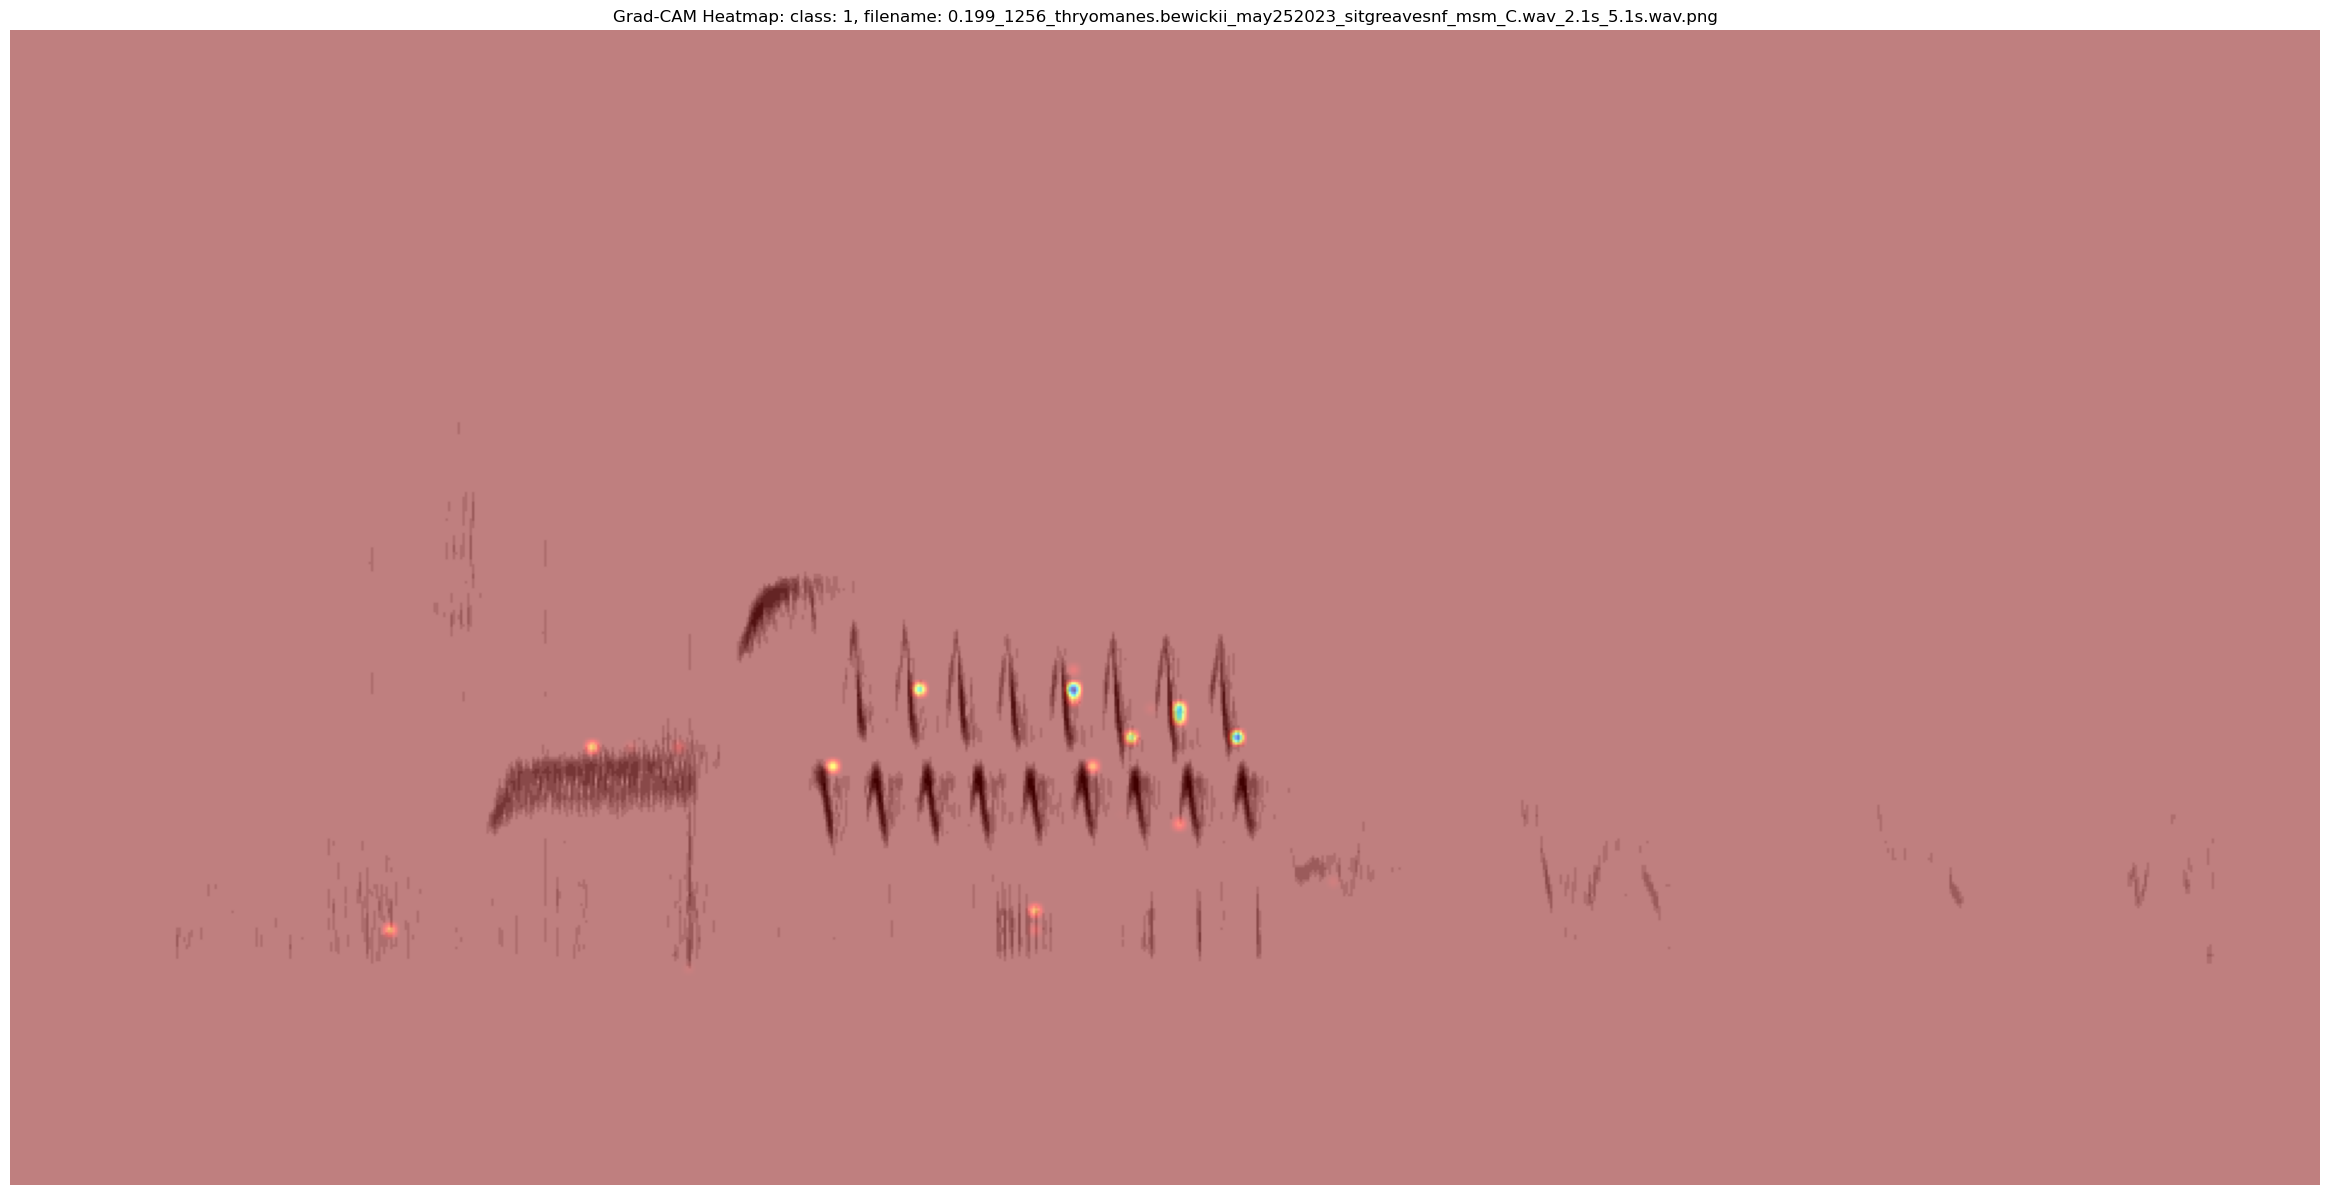

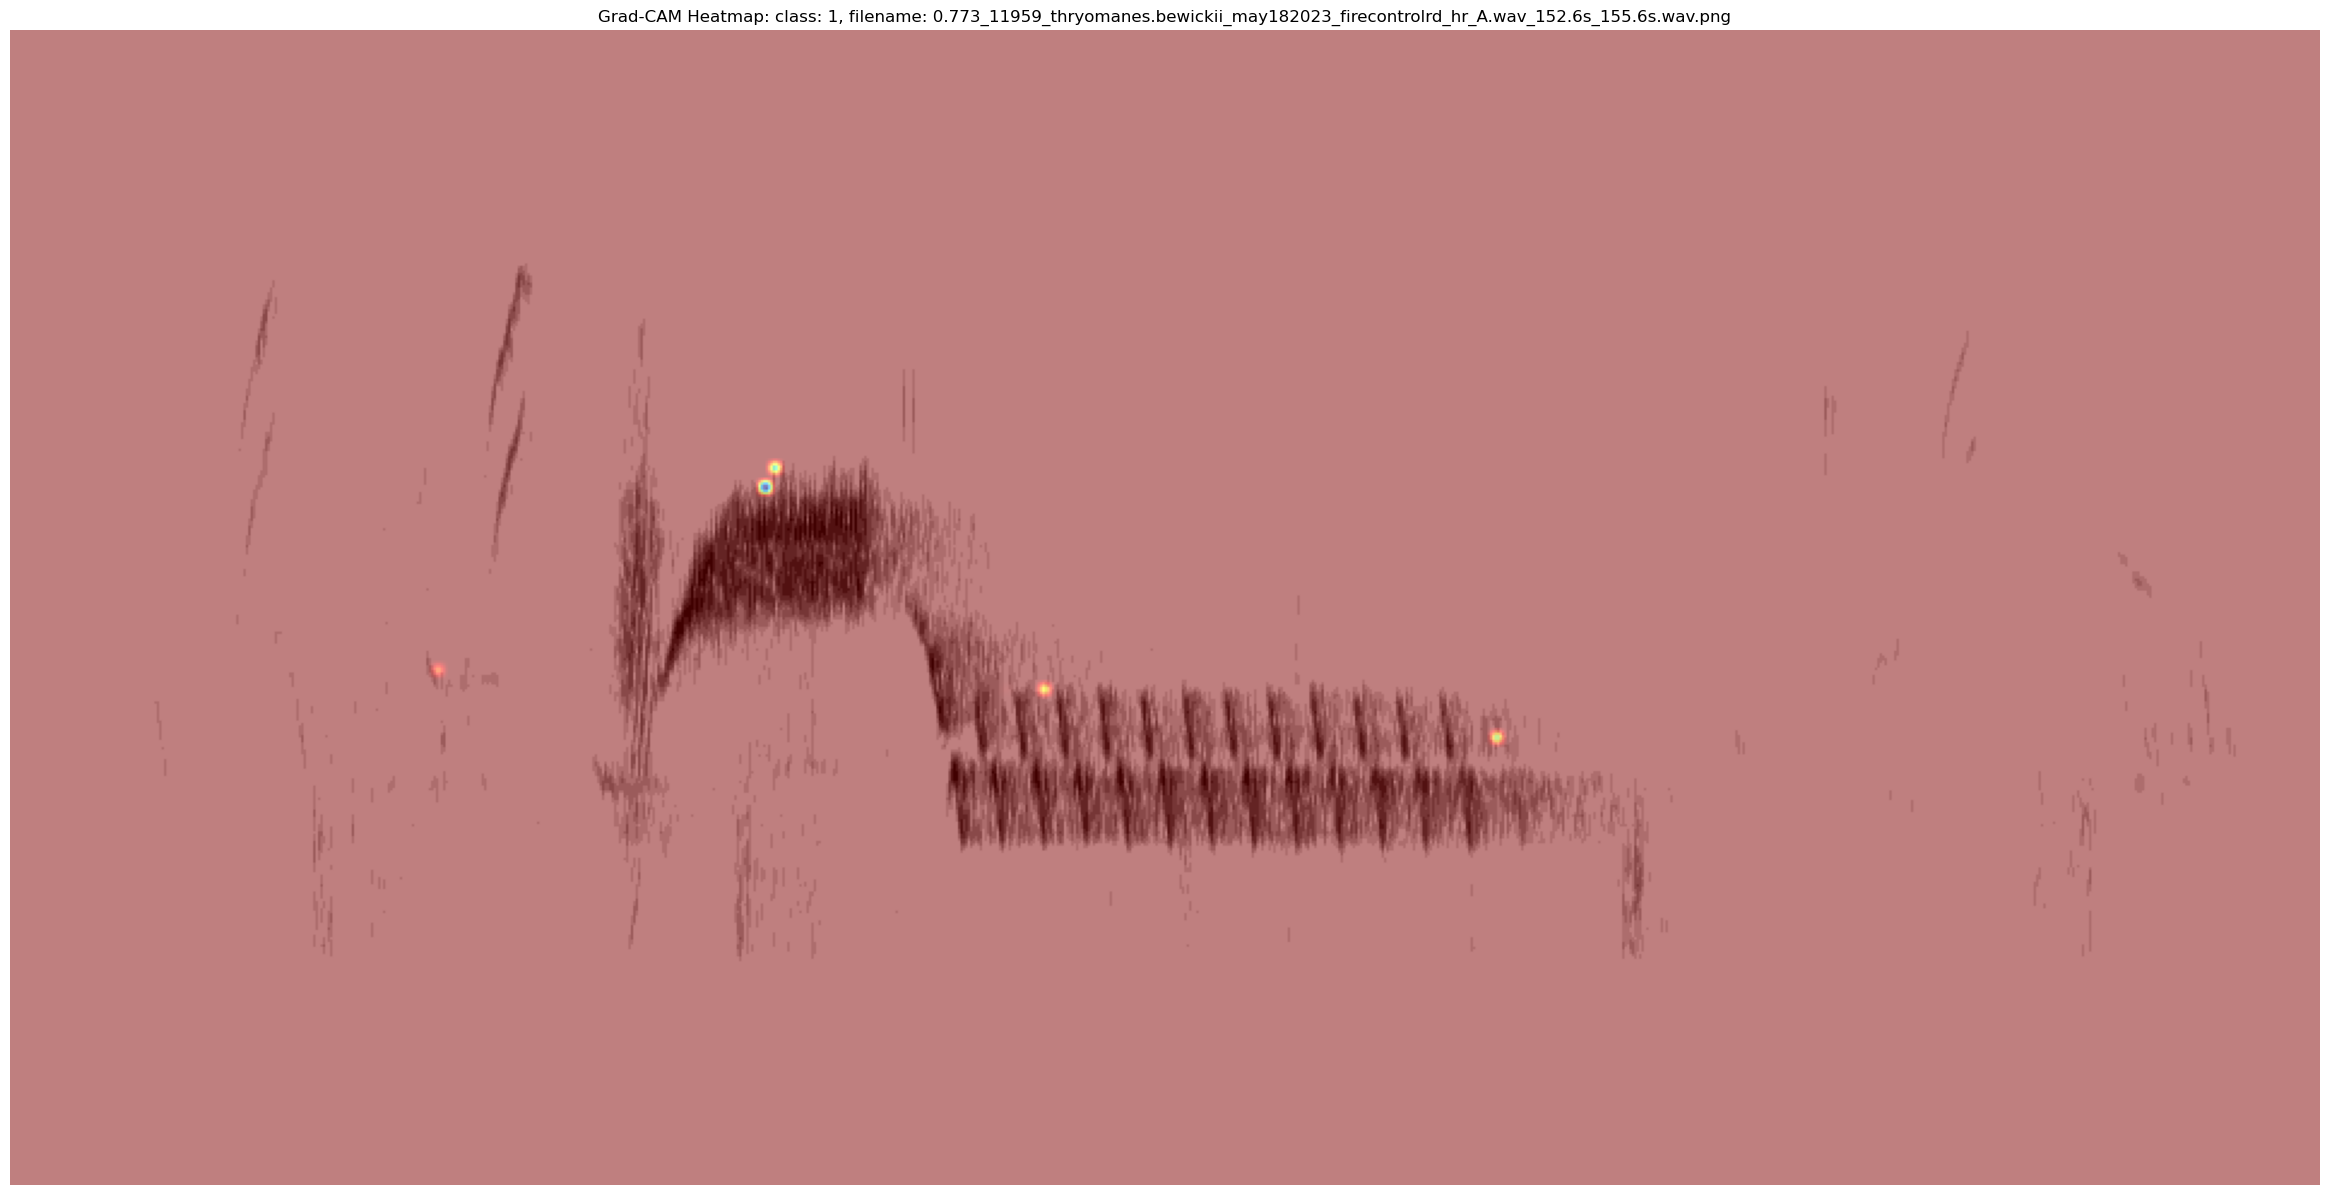

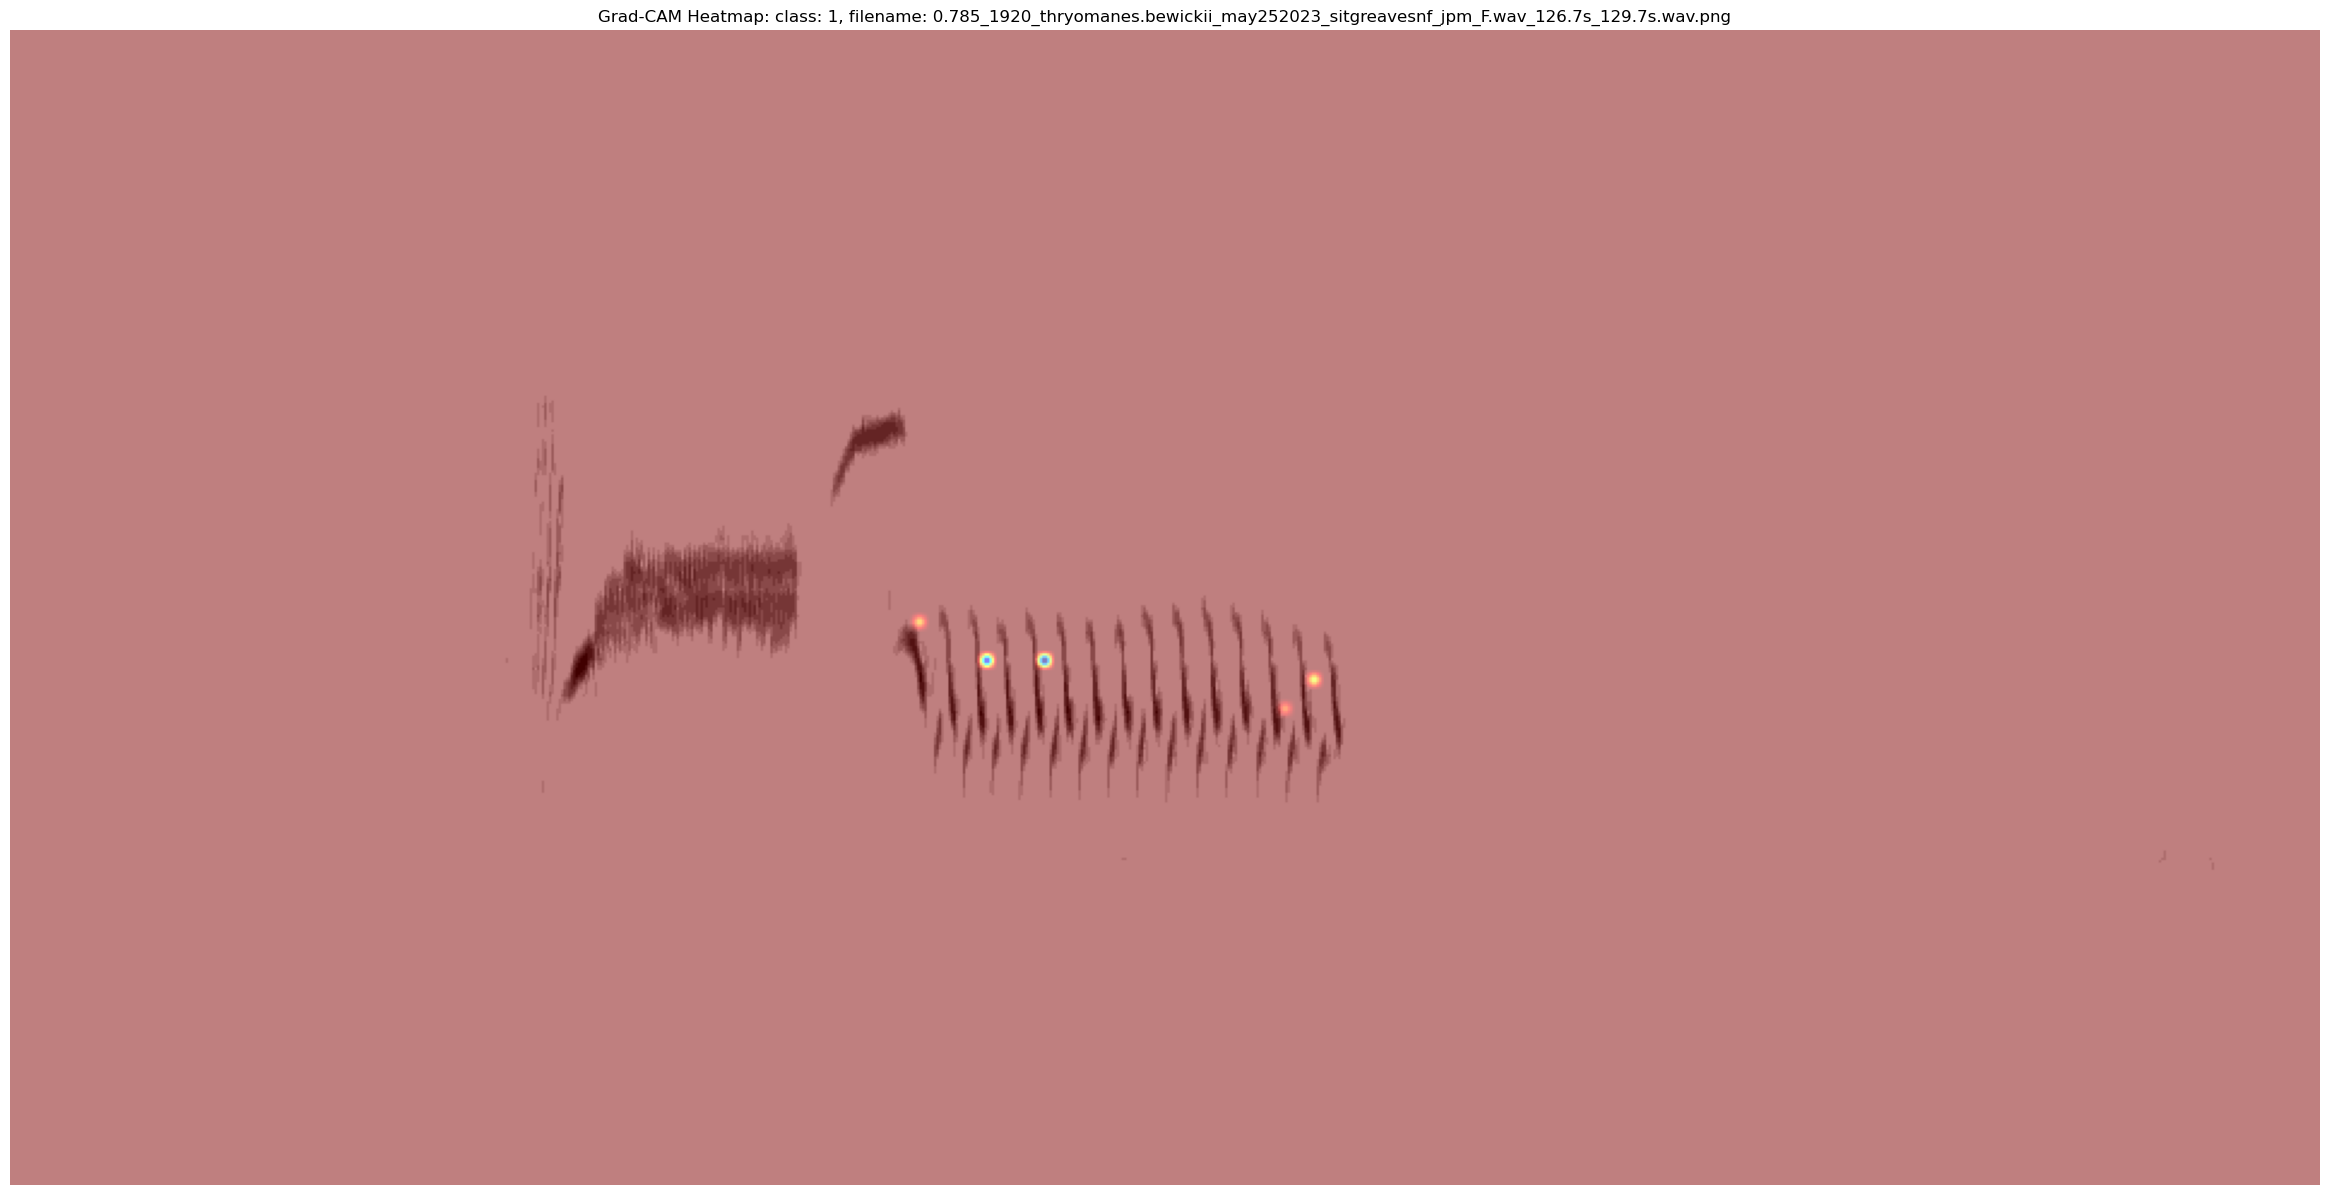

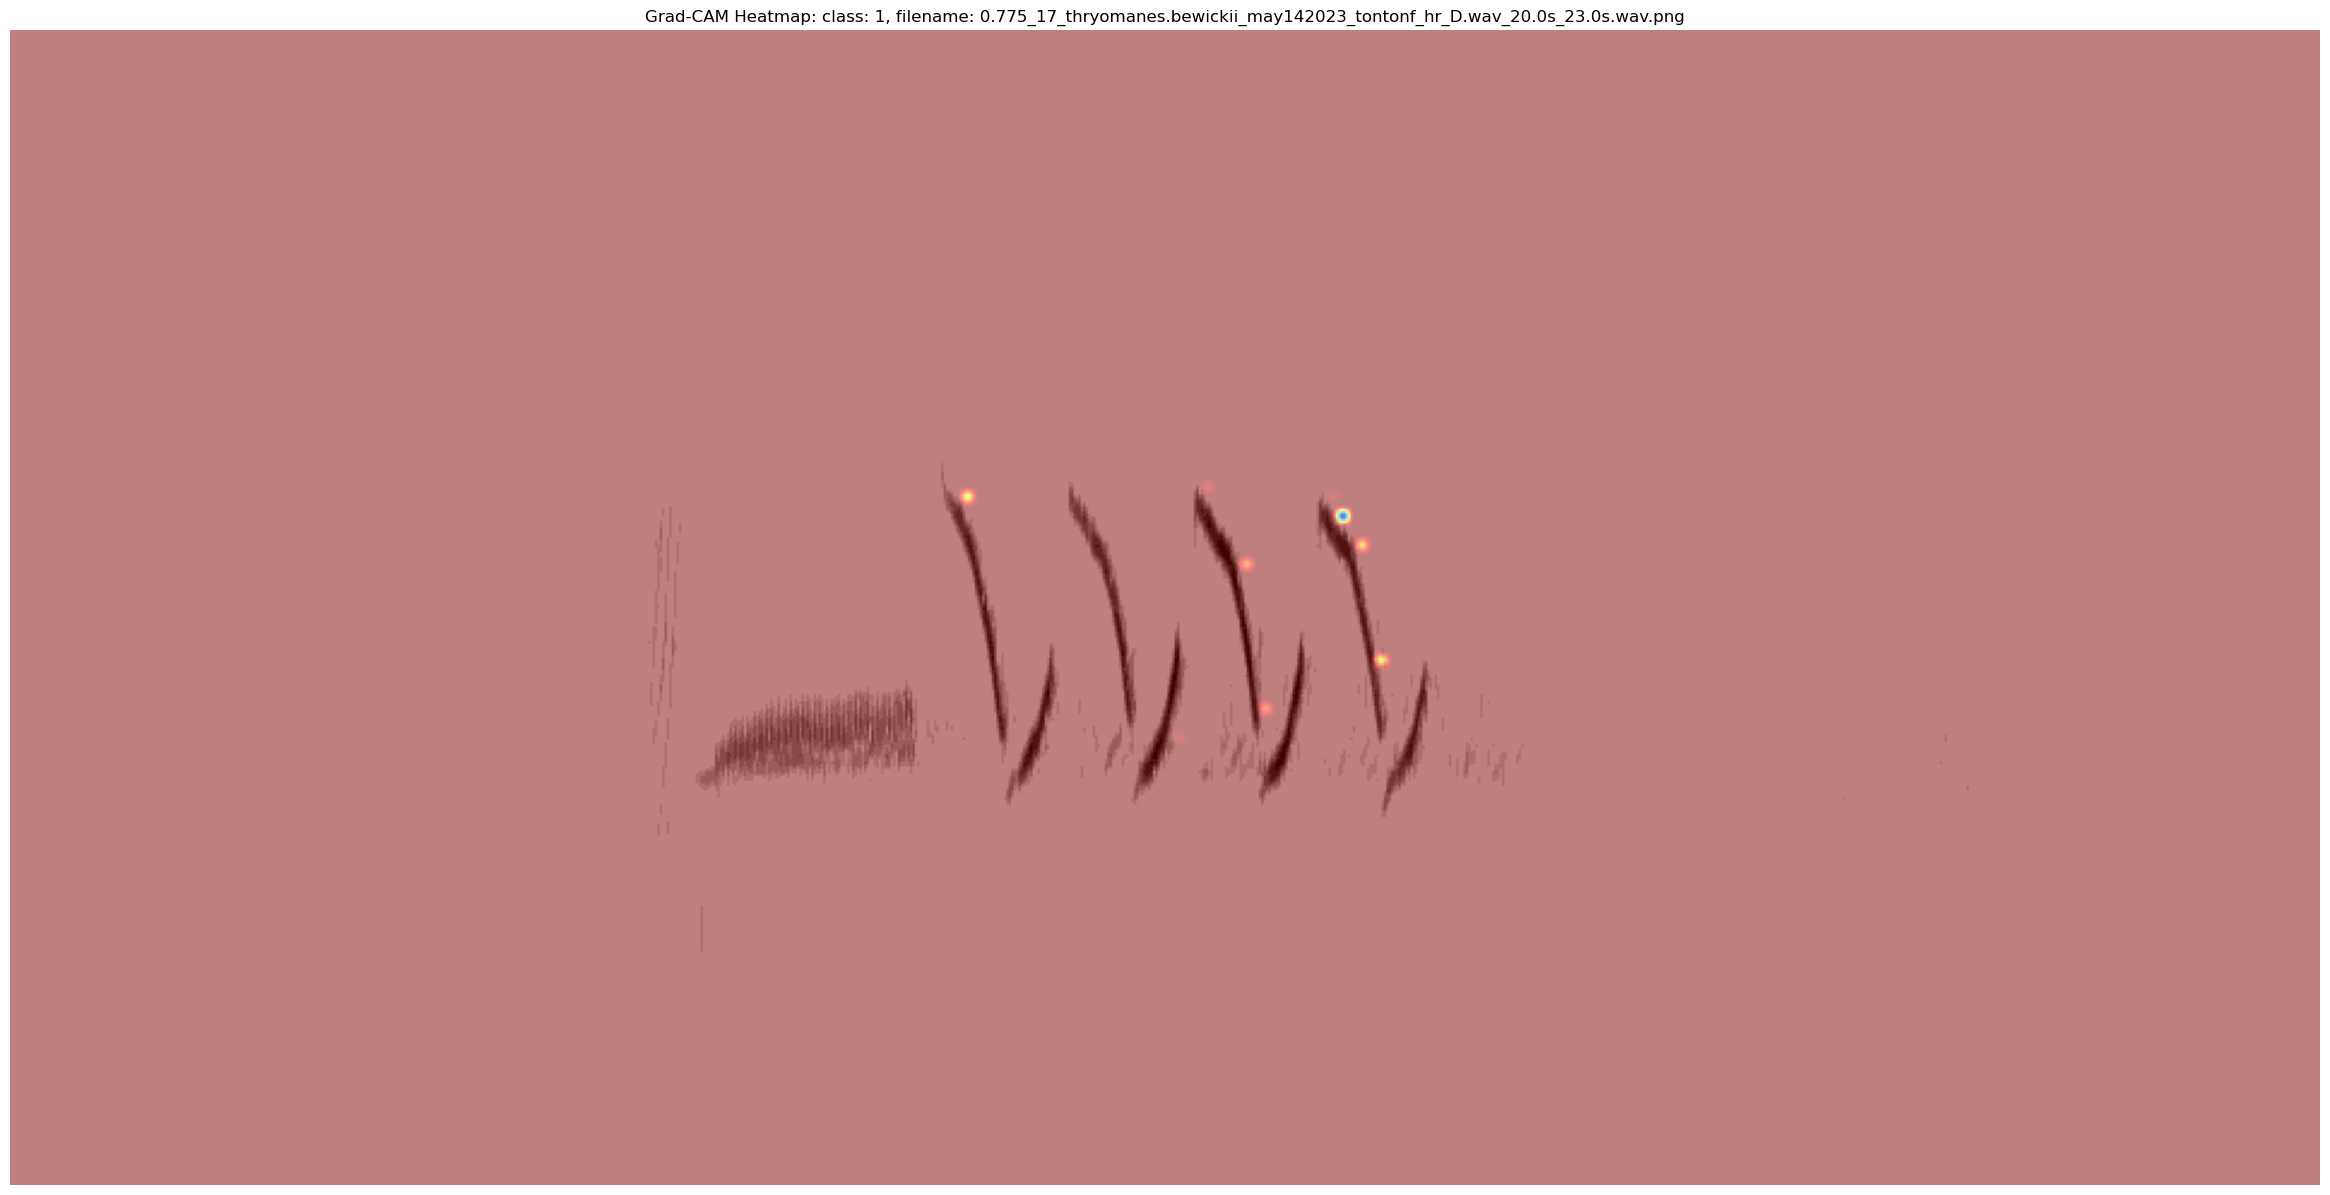

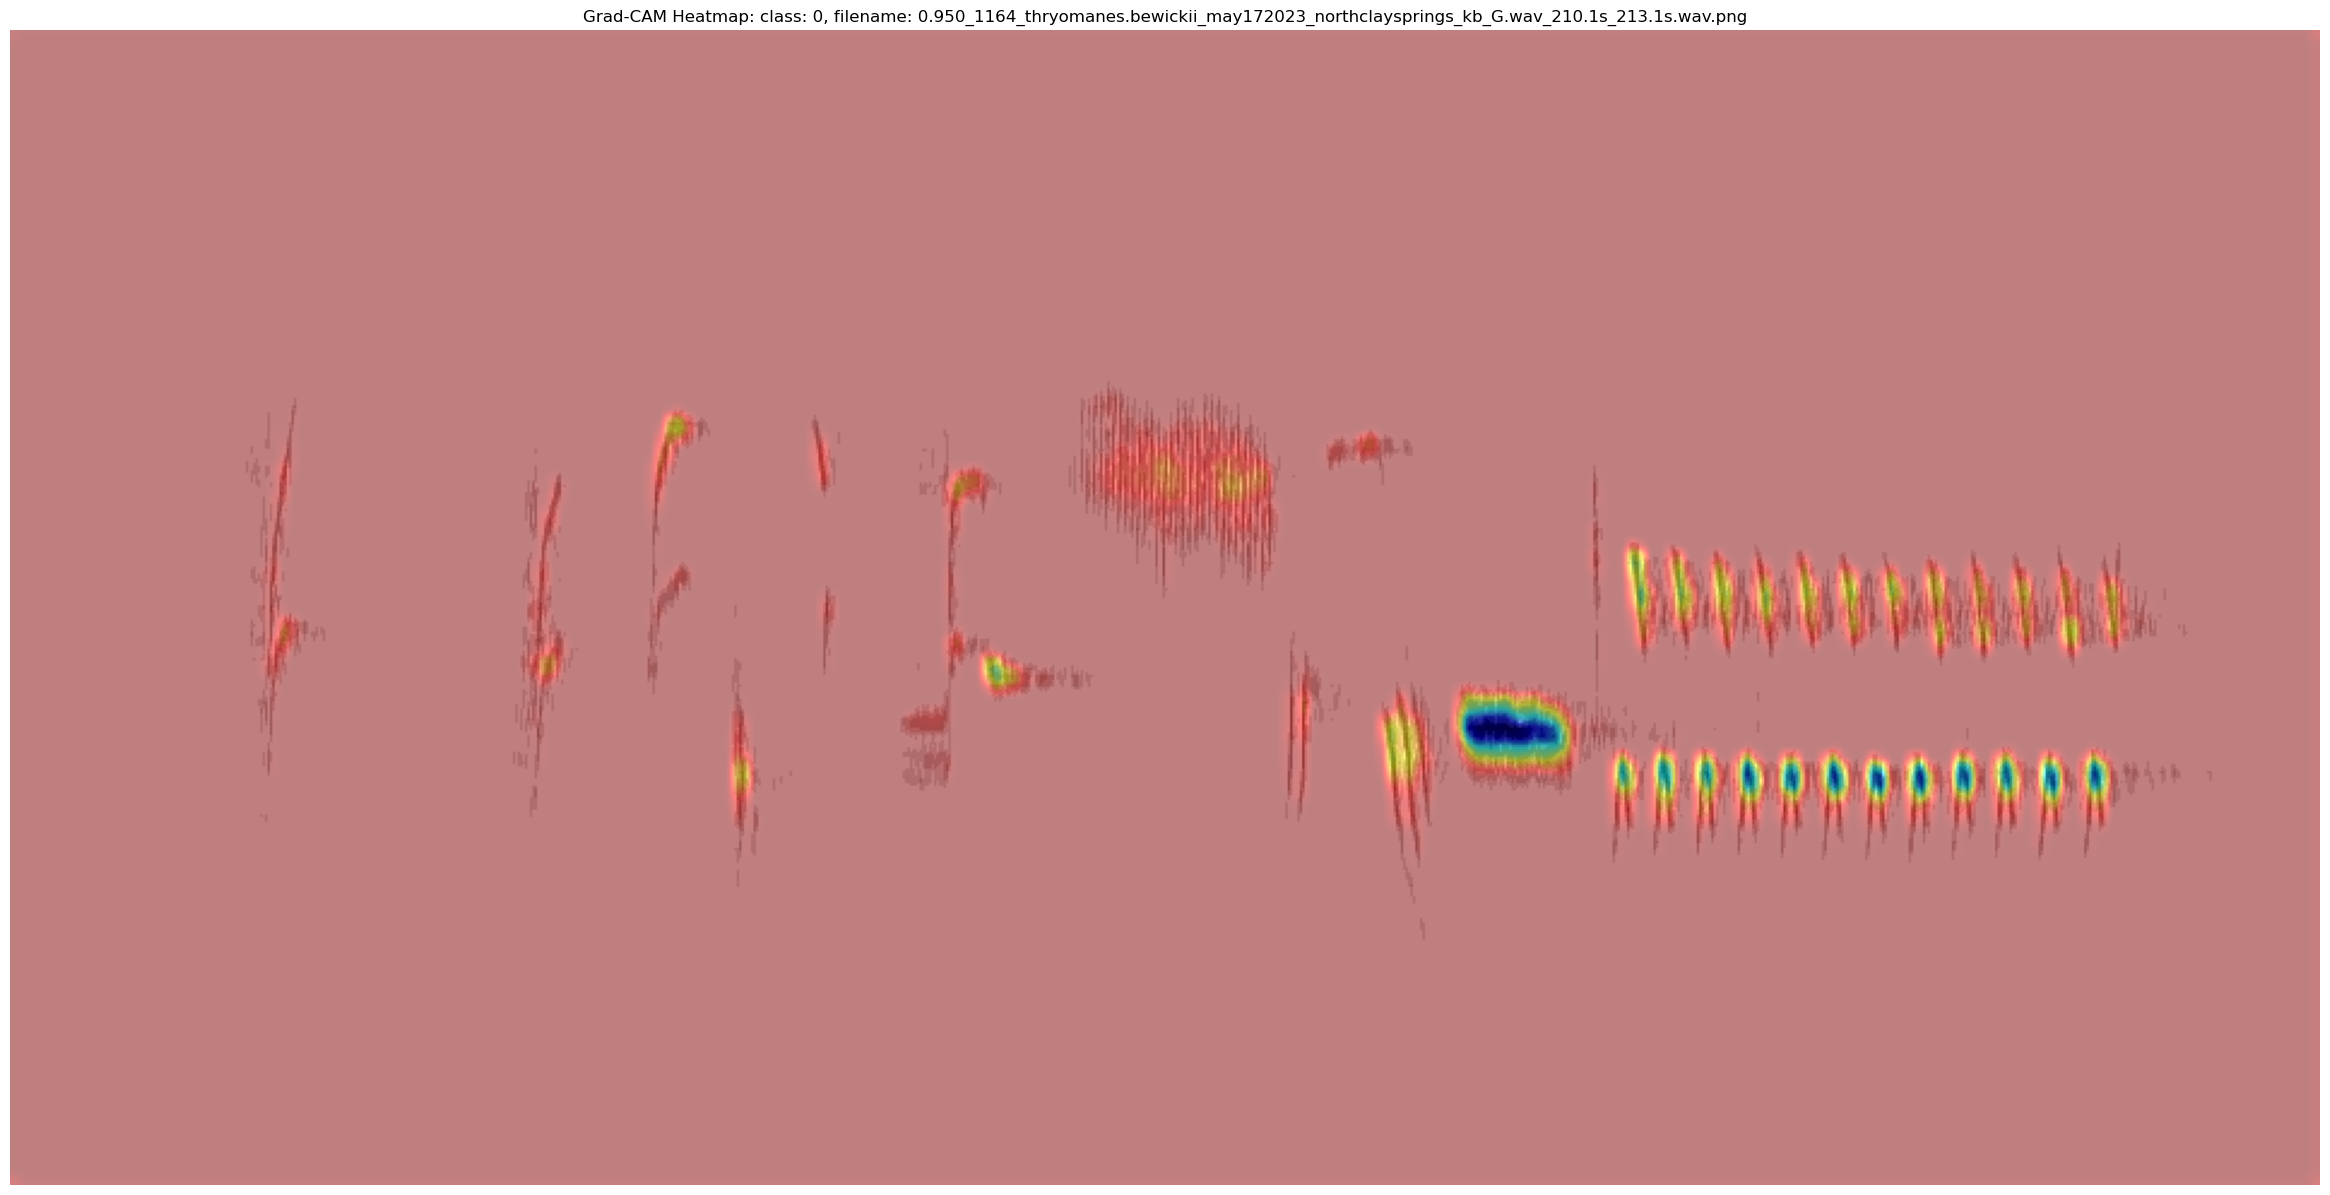

In [58]:
for i, test_image in enumerate(test_images):
    #ouptutForShap(shap_values, test_image, test_labels[i], tets_image_fileNames[i], i)
    #showLimeOutput(explainer, lime_cnn_model_wrapper, segmentation_fn, test_image, test_labels[i], tets_image_fileNames[i], i)
    showGradcamOuputput(test_image, test_labels[i], tets_image_fileNames[i], i) 

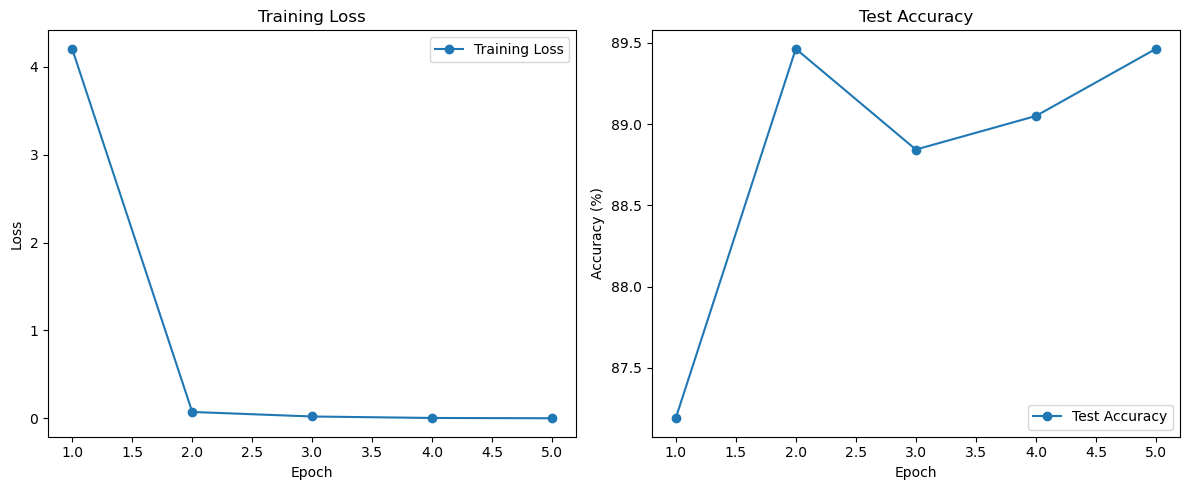

In [59]:
# Function to plot the loss and accuracy
def plot_metrics(train_loss_list, test_accuracy_list):
    epochs = range(1, len(train_loss_list) + 1)

    # Plot Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_list, '-o', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, test_accuracy_list, '-o', label='Test Accuracy')
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
    
# Plot loss and accuracy
plot_metrics(train_loss_list, test_accuracy_list)


Accuracy of the model on the test images: 89.46%


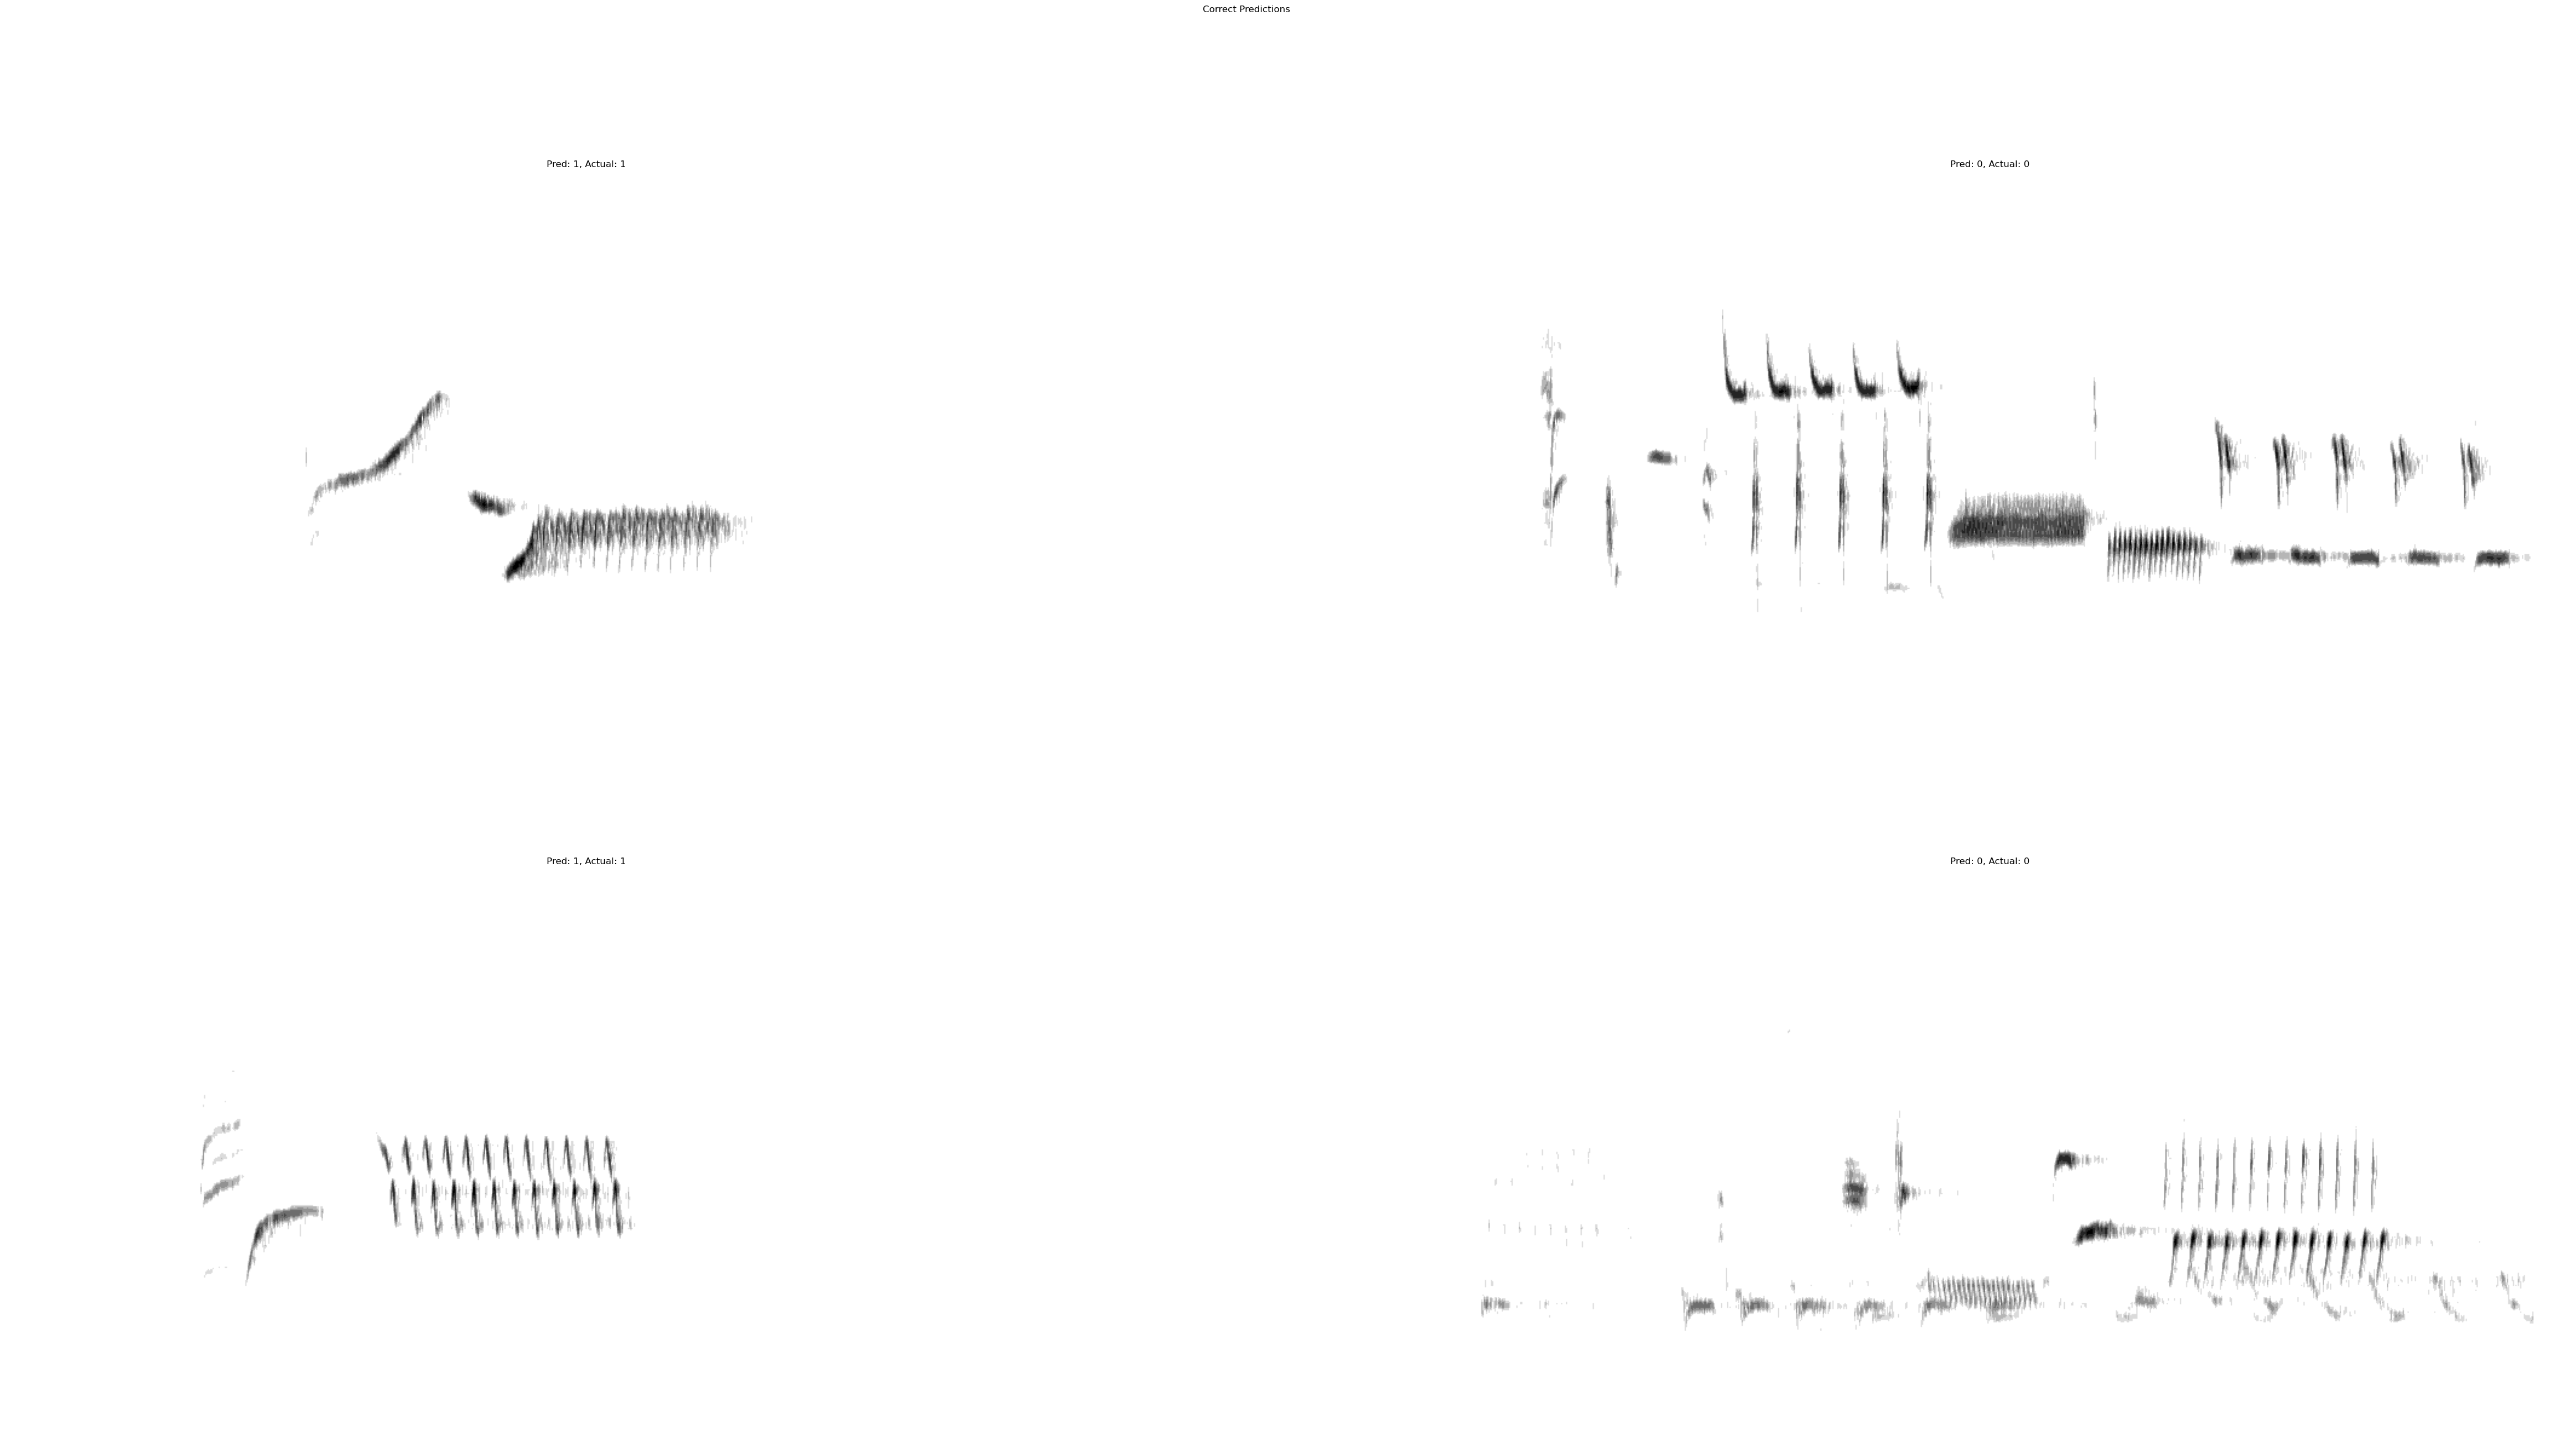

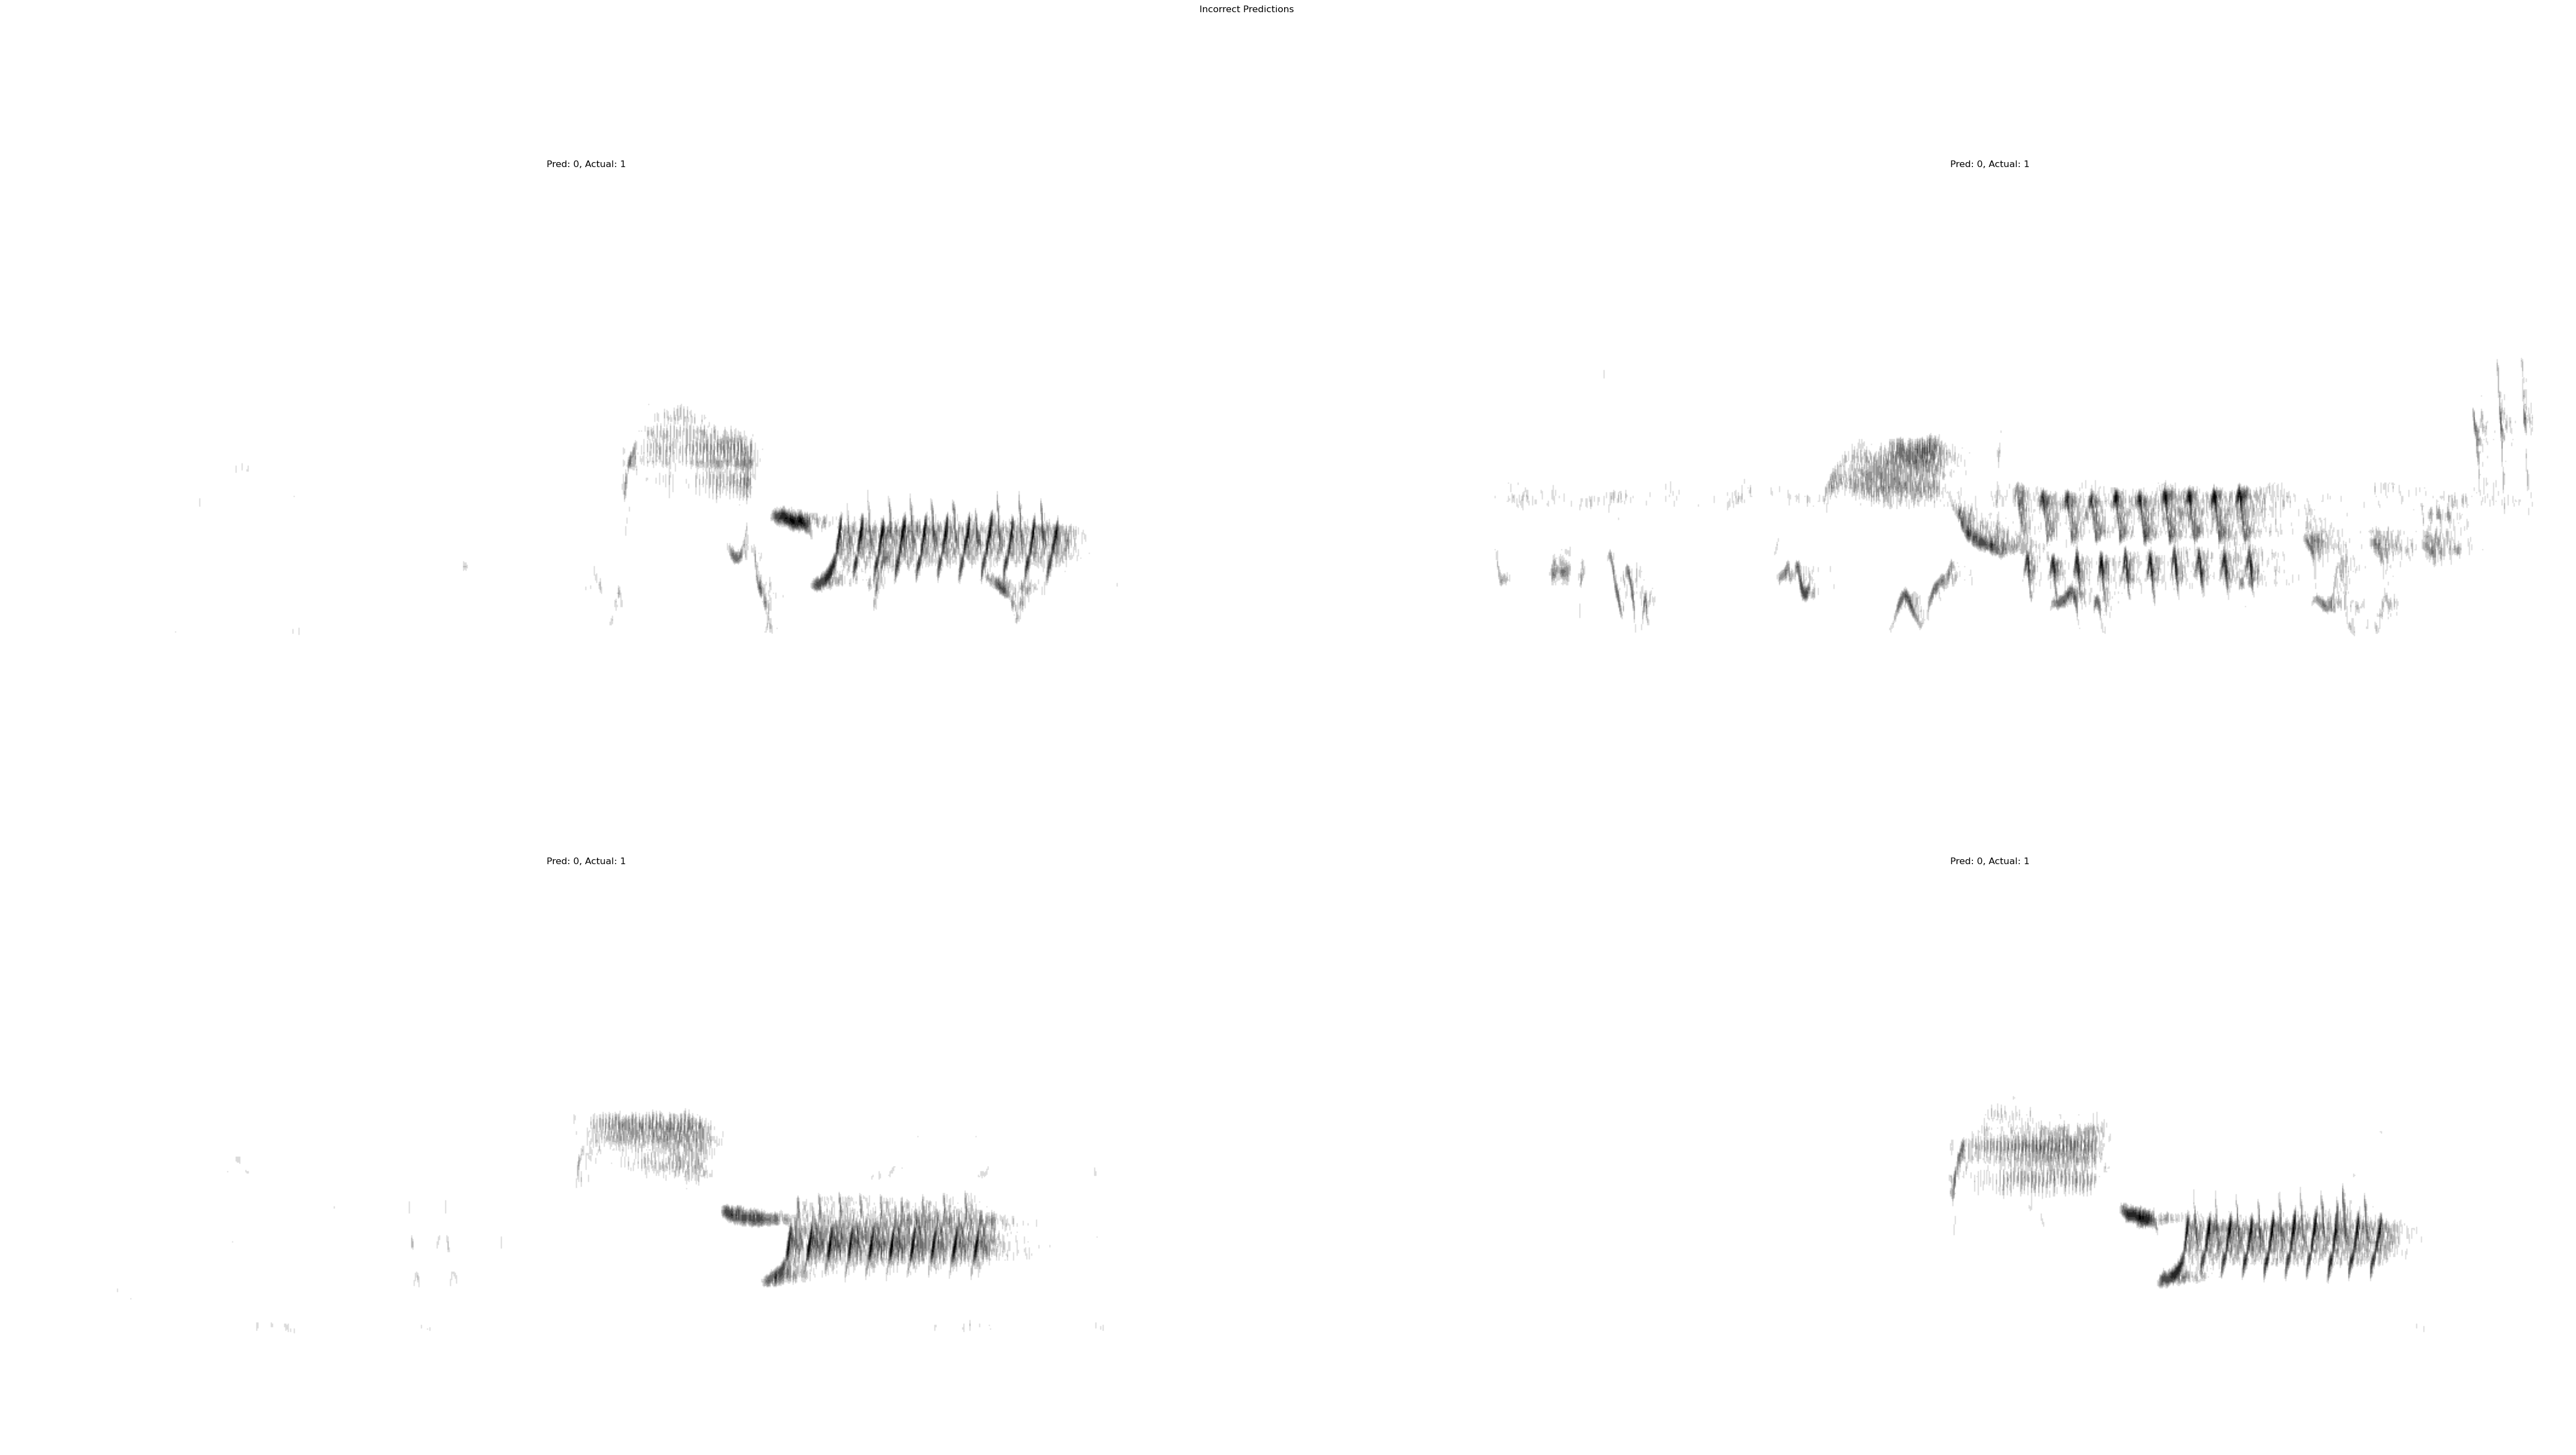

In [60]:
# Plot correct and incorrect predictions
def plot_images(images, labels, predictions, title, maxNumberOfImage):
    rows, cols = calculate_grid_size(maxNumberOfImage)
    plt.figure(figsize=(cols * 30, rows * 15))
    for i in range(maxNumberOfImage): # len(images)
        plt.subplot(rows, cols, i + 1)
        imshow(images[i])
        plt.title(f'Pred: {predictions[i]}, Actual: {labels[i]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Helper function to display images
def imshow(img):
    # img = img / 2 + 0.5  # Unnormalize the image
    # npimg = img.cpu().numpy()  # Ensure the tensor is on the CPU before displaying
    # plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
    img = img / 2 + 0.5  # Unnormalize the image
    npimg = img.cpu().numpy()  # Ensure the tensor is on the CPU before displaying
    npimg = npimg.squeeze()  # Remove the channel dimension (from (1, H, W) to (H, W))
    plt.imshow(npimg, cmap='gray')  # Display as a grayscale image
    
# Testing function that plots correct and incorrect predictions
def test_model_with_plots(model, test_loader, device='cpu', maxNumberOfImage = 9):
    model.eval()  # Set the model to evaluation mode
    correct_images, incorrect_images = [], []
    correct_labels, incorrect_labels = [], []
    correct_preds, incorrect_preds = [], []

    with torch.no_grad():  # No need to track gradients for testing
        for images, labels, fileNames in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            for i in range(len(labels)):
                if predicted[i] == labels[i] :
                    correct_images.append(images[i])
                    correct_labels.append(labels[i].item())
                    correct_preds.append(predicted[i].item())
                elif predicted[i] != labels[i] :
                    incorrect_images.append(images[i])
                    incorrect_labels.append(labels[i].item())
                    incorrect_preds.append(predicted[i].item())

    print(f'Accuracy of the model on the test images: {100 * len(correct_images) / len(test_loader.dataset):.2f}%')
    # Plot correct predictions
    plot_images(correct_images, correct_labels, correct_preds, 'Correct Predictions', maxNumberOfImage)
    # Plot incorrect predictions
    plot_images(incorrect_images, incorrect_labels, incorrect_preds, 'Incorrect Predictions', maxNumberOfImage)


import math
def calculate_grid_size(n_images):
    cols = math.ceil(math.sqrt(n_images))  # Number of columns
    rows = math.ceil(n_images / cols)      # Number of rows based on columns
    return rows, cols

# Test the model and plot correct and incorrect predictions
test_model_with_plots(model, test_loader, device=device, maxNumberOfImage = 4)

In [61]:
# Try LRP, does not work
import matplotlib.pyplot as plt
from zennit.composites import EpsilonPlusFlat
from zennit.attribution import Gradient

model = SimpleCNN().to(device)
model.eval()


# Extract one image and label from train_loader (batch size = 1)
input_image, label = next(iter(train_loader))
input_image = input_image[0].unsqueeze(0).to(device)  # Get the first image and add batch dimension
label = label[0].to(device)  # Get the first label

# Define the LRP composite rule
composite = EpsilonPlusFlat()  # Commonly used composite method

# Perform the forward pass with LRP
with Gradient(model=model, composite=composite) as lrp:
    output = model(input_image)  # Forward pass
    print(f"Output: {output.shape}")
    print(f"Label: {label}")
    print(f"Selected class score: {output[0, label]}")
    relevance = lrp(output[0, label])  # For the first image, access the true class


# Project the relevance map to 2D for visualization

# Assuming `relevance` is the output relevance tensor from LRP
# Squeeze the batch dimension and convert to numpy
relevance_map = relevance.squeeze().cpu().numpy()
# Normalize the relevance map for better visualization
relevance_map = (relevance_map - relevance_map.min()) / (relevance_map.max() - relevance_map.min())
# Plot the input image and relevance map
plt.figure(figsize=(12, 6))
# Original input image
plt.subplot(1, 2, 1)
plt.imshow(input_image.squeeze().cpu().numpy(), cmap='gray')
plt.title('Input Image (Grayscale)')
plt.axis('off')
# Relevance heatmap
plt.subplot(1, 2, 2)
plt.imshow(relevance_map, cmap='seismic', interpolation='nearest')  # Use 'seismic' for red-blue coloring
plt.title('LRP Relevance Map')
plt.axis('off')
plt.show()

ValueError: too many values to unpack (expected 2)

In [15]:
import torch
from zennit.image import imgify
from zennit.attribution import Gradient
from zennit.image import imsave
input = torch.randn(8, 1, 960, 480, requires_grad=True).to(device)
with Gradient(model) as attributor:
    output, relevance = attributor(input)
for n, (inp, rel) in enumerate(zip(input, relevance)):
    imsave(f'input_{n:03d}.png', inp.detach().cpu())
    imsave(f'relevance_{n:03d}.png', rel.cpu())
    imgify(rel.cpu(), grid=True).show()